In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [7]:
df=pd.read_csv('/content/drive/MyDrive/Kuliah/Data/kz.csv')
df

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id
0,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18
1,2020-04-24 11:50:39 UTC,2294359932054536986,1515966223509089906,2.268105e+18,electronics.tablet,samsung,162.01,1.515916e+18
2,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18
3,2020-04-24 14:37:43 UTC,2294444024058086220,2273948319057183658,2.268105e+18,electronics.audio.headphone,huawei,77.52,1.515916e+18
4,2020-04-24 19:16:21 UTC,2294584263154074236,2273948316817424439,2.268105e+18,NaN,karcher,217.57,1.515916e+18
...,...,...,...,...,...,...,...,...
2633516,2020-11-21 10:10:01 UTC,2388440981134693942,1515966223526602848,2.268105e+18,electronics.smartphone,oppo,138.87,1.515916e+18
2633517,2020-11-21 10:10:13 UTC,2388440981134693943,1515966223509089282,2.268105e+18,electronics.smartphone,apple,418.96,1.515916e+18
2633518,2020-11-21 10:10:30 UTC,2388440981134693944,1515966223509089917,2.268105e+18,appliances.personal.scales,vitek,12.48,1.515916e+18
2633519,2020-11-21 10:10:30 UTC,2388440981134693944,2273948184839454837,2.268105e+18,NaN,moulinex,41.64,1.515916e+18


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2633521 entries, 0 to 2633520
Data columns (total 8 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   order_id       int64  
 2   product_id     int64  
 3   category_id    float64
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        float64
dtypes: float64(3), int64(2), object(3)
memory usage: 160.7+ MB


# **Data Preprocessing**

### Fix Data Types

In [9]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
df['month'] = df['event_time'].dt.to_period('M')
df['user_id'] = df['user_id'].astype('Int64')
df['order_id'] = df['order_id'].astype('Int64')

### Feature check

In [10]:
print("\n=== Date Range ===")
print(f"From: {df['event_time'].min()}")
print(f"To:   {df['event_time'].max()}")

print("\n=== Key Metrics ===")
print(f"Total rows:         {len(df):,}")
print(f"Unique orders:      {df['order_id'].nunique():,}")
print(f"Unique users:       {df['user_id'].nunique():,}")
print(f"Unique products:    {df['product_id'].nunique():,}")
print(f"Unique categories:  {df['category_code'].nunique():,}")
print(f"Unique brands:      {df['brand'].nunique():,}")

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Price Stats ===")
print(f"Min:  {df['price'].min():.2f}")
print(f"Max:  {df['price'].max():.2f}")
print(f"Mean: {df['price'].mean():.2f}")
print(f"Zero: {(df['price'] == 0).sum():,}")

print("\n=== Duplicate Analysis ===")
dups = df.duplicated().sum()
print(f"Duplicate rows:   {dups:,}")
print(f"Clean rows:       {len(df) - dups:,}")

print("\n=== Monthly Volume ===")
monthly = df.groupby('month').agg(
    orders   = ('order_id', 'nunique'),
    users    = ('user_id',  'nunique'),
    revenue  = ('price',    'sum')
).sort_index()
print(monthly)

print("\n=== Repeat Buyer Analysis ===")
repeat = df.groupby('user_id')['order_id'].nunique()
print(f"Buyers with 1 order:    {(repeat == 1).sum():,}")
print(f"Buyers with 2+ orders:  {(repeat >= 2).sum():,}")
print(f"Buyers with 3+ orders:  {(repeat >= 3).sum():,}")
print(f"Buyers with 5+ orders:  {(repeat >= 5).sum():,}")
print(f"Avg orders per buyer:   {repeat.mean():.2f}")
print(f"Max orders per buyer:   {repeat.max():,}")


=== Date Range ===
From: 1970-01-01 00:33:40+00:00
To:   2020-11-21 10:10:30+00:00

=== Key Metrics ===
Total rows:         2,633,521
Unique orders:      1,435,266
Unique users:       98,262
Unique products:    25,113
Unique categories:  510
Unique brands:      23,021

=== Missing Values ===
event_time             0
order_id               0
product_id             0
category_id       431954
category_code     612202
brand             506005
price             431954
user_id          2069352
month                  0
dtype: int64

=== Price Stats ===
Min:  0.00
Max:  50925.90
Mean: 154.09
Zero: 121

=== Duplicate Analysis ===
Duplicate rows:   675
Clean rows:       2,632,846

=== Monthly Volume ===
         orders  users      revenue
month                              
1970-01    9013    168   2174872.60
2020-01  130703   1876  26494398.53
2020-02  157085   2322  31836933.60
2020-03  156134   2658  37550969.39
2020-04   41649   5606   7689624.61
2020-05  129626  17857  28346976.05
2020-06 

In [11]:
# How many rows have user_id vs missing
has_user = df['user_id'].notna()
print(f"Rows WITH user_id:     {has_user.sum():,}  ({has_user.mean()*100:.1f}%)")
print(f"Rows WITHOUT user_id:  {(~has_user).sum():,}  ({(~has_user).mean()*100:.1f}%)")

# Check if missing user_id rows have valid orders
missing_user = df[df['user_id'].isna()]
print(f"\nAmong rows with missing user_id:")
print(f"  Unique orders:  {missing_user['order_id'].nunique():,}")
print(f"  Date range:     {missing_user['event_time'].min()} → {missing_user['event_time'].max()}")
print(f"  Avg price:      {missing_user['price'].mean():.2f}")
print(f"  Monthly dist:")
print(missing_user['month'].value_counts().sort_index())

# Check rows WITH user_id
valid_user = df[df['user_id'].notna()]
print(f"\nAmong rows WITH valid user_id:")
print(f"  Total rows:     {len(valid_user):,}")
print(f"  Unique orders:  {valid_user['order_id'].nunique():,}")
print(f"  Unique users:   {valid_user['user_id'].nunique():,}")
print(f"  Date range:     {valid_user['event_time'].min()} → {valid_user['event_time'].max()}")
print(f"  Monthly dist:")
print(valid_user.groupby('month').agg(
    orders=('order_id','nunique'),
    users=('user_id','nunique')
).sort_index())

Rows WITH user_id:     564,169  (21.4%)
Rows WITHOUT user_id:  2,069,352  (78.6%)

Among rows with missing user_id:
  Unique orders:  1,056,723
  Date range:     1970-01-01 00:33:40+00:00 → 2020-11-19 16:20:21+00:00
  Avg price:      135.43
  Monthly dist:
month
1970-01     18324
2020-01    251775
2020-02    305277
2020-03    295822
2020-04     46006
2020-05    184008
2020-06    362268
2020-07     90662
2020-08    201181
2020-09    291478
2020-10     12132
2020-11     10419
Freq: M, Name: count, dtype: int64

Among rows WITH valid user_id:
  Total rows:     564,169
  Unique orders:  400,538
  Unique users:   98,262
  Date range:     1970-01-01 00:33:40+00:00 → 2020-11-21 10:10:30+00:00
  Monthly dist:
         orders  users
month                 
1970-01     788    168
2020-01    9580   1876
2020-02   11483   2322
2020-03   12093   2658
2020-04    9003   5606
2020-05   30461  17857
2020-06   28988  14375
2020-07   57663  31152
2020-08   74019  36564
2020-09   51050  20413
2020-10   705

### Check date anomalies

In [12]:
print("\n=== 1970 Date Investigation ===")
df_1970 = df[df['month'] == '1970-01']
print(f"Rows with 1970 date:    {len(df_1970):,}")
print(f"Has user_id:            {df_1970['user_id'].notna().sum():,}")
print(f"Sample event_time values:")
print(df_1970['event_time'].head(10).tolist())
print(f"\nSample order_ids:")
print(df_1970['order_id'].head(5).tolist())


=== 1970 Date Investigation ===
Rows with 1970 date:    19,631
Has user_id:            1,307
Sample event_time values:
[Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC'), Timestamp('1970-01-01 00:33:40+0000', tz='UTC')]

Sample order_ids:
[2340102742254551453, 2340102742439100830, 2340102742439100830, 2340102742439100830, 2340102742439100830]


### Basic Cleaning

In [13]:
print("\n=== Preview After Basic Cleaning ===")

df_clean = df[
    (df['user_id'].notna()) &          # must have user_id
    (df['month'] != '1970-01') &       # remove corrupted dates
    (df['price'] > 0)                  # remove zero prices
].copy()

print(f"Rows after basic cleaning: {len(df_clean):,}")
print(f"Unique users:              {df_clean['user_id'].nunique():,}")
print(f"Unique orders:             {df_clean['order_id'].nunique():,}")
print(f"\nMonthly distribution:")
print(df_clean.groupby('month').agg(
    orders=('order_id','nunique'),
    users=('user_id','nunique'),
    revenue=('price','sum')
).sort_index())

print(f"\nRepeat buyers after cleaning:")
repeat_clean = df_clean.groupby('user_id')['order_id'].nunique()
print(f"Buyers with 1 order:    {(repeat_clean == 1).sum():,}")
print(f"Buyers with 2+ orders:  {(repeat_clean >= 2).sum():,}")
print(f"Buyers with 3+ orders:  {(repeat_clean >= 3).sum():,}")
print(f"Avg orders per buyer:   {repeat_clean.mean():.2f}")


=== Preview After Basic Cleaning ===
Rows after basic cleaning: 562,823
Unique users:              98,239
Unique orders:             399,728

Monthly distribution:
         orders  users      revenue
month                              
2020-01    9579   1876   1774466.94
2020-02   11480   2321   2267809.88
2020-03   12092   2657   2897486.26
2020-04    9002   5605   1704422.41
2020-05   30460  17856   7768637.79
2020-06   28980  14370   7691244.33
2020-07   57660  31150  16354029.27
2020-08   74019  36564  27982605.44
2020-09   51049  20412  17152310.57
2020-10   70594  15051  19765680.76
2020-11   44813   8910  11961511.52

Repeat buyers after cleaning:
Buyers with 1 order:    43,982
Buyers with 2+ orders:  54,257
Buyers with 3+ orders:  33,540
Avg orders per buyer:   4.07


### Handle Duplicate rows & Null value

In [14]:
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
after  = len(df_clean)

print(f'Duplicate rows removed : {before - after:,}')
print(f'Rows remaining         : {after:,}')

Duplicate rows removed : 674
Rows remaining         : 562,149


In [15]:
#Fill nulls di kolom non-kritis ────────────────────
print('Before fill:')
print(f"  category_code nulls : {df_clean['category_code'].isnull().sum():,}")
print(f"  brand nulls         : {df_clean['brand'].isnull().sum():,}")

df_clean['category_code'] = df_clean['category_code'].fillna('unknown')
df_clean['brand']         = df_clean['brand'].fillna('unknown')

print('\nAfter fill:')
print(f"  category_code nulls : {df_clean['category_code'].isnull().sum()}")
print(f"  brand nulls         : {df_clean['brand'].isnull().sum()}")

Before fill:
  category_code nulls : 128,749
  brand nulls         : 27,114

After fill:
  category_code nulls : 0
  brand nulls         : 0


### Fix data type
- Fix category_id (float64 → string)
- category_id saat ini float64 karena ada NaN sebelumnya
- Setelah null dibuang (via user_id filter), aman di-convert ke string


In [16]:
df_clean['category_id'] = df_clean['category_id'].astype('int64').astype('str')

print(f"category_id dtype : {df_clean['category_id'].dtype}")
print(f"Sample values     : {df_clean['category_id'].unique()[:3].tolist()}")

category_id dtype : object
Sample values     : ['2268105426648171008', '2268105430162997760', '2268105471367840000']


### Extract time features

In [17]:
df_clean['date']         = df_clean['event_time'].dt.date
df_clean['hour']         = df_clean['event_time'].dt.hour
df_clean['day_of_week']  = df_clean['event_time'].dt.dayofweek   # 0 = Monday

# Top-level category: 'electronics.smartphone' → 'electronics'
df_clean['category_top'] = df_clean['category_code'].apply(
    lambda x: x.split('.')[0] if x != 'unknown' else 'unknown'
)

print('Time features extracted:')
print(f"  date         — sample: {df_clean['date'].iloc[0]}")
print(f"  hour         — range: {df_clean['hour'].min()} – {df_clean['hour'].max()}")
print(f"  day_of_week  — range: {df_clean['day_of_week'].min()} – {df_clean['day_of_week'].max()} (0=Mon, 6=Sun)")
print(f"  category_top — unique: {df_clean['category_top'].nunique()} values")
print(f"  Top 5: {df_clean['category_top'].value_counts().head().index.tolist()}")

Time features extracted:
  date         — sample: 2020-04-24
  hour         — range: 0 – 23
  day_of_week  — range: 0 – 6 (0=Mon, 6=Sun)
  category_top — unique: 14 values
  Top 5: ['electronics', 'appliances', 'unknown', 'computers', 'furniture']


### Final validation

In [18]:
print('=' * 58)
print('  FINAL CLEAN DATASET — VALIDATION')
print('=' * 58)

print(f'\nShape         : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

print(f'\nData types:')
print(df_clean.dtypes)

print(f'\nNull values per column:')
null_check = df_clean.isnull().sum()
print(null_check[null_check > 0] if null_check.sum() > 0 else '  None — dataset is clean')

print(f'\nDate range    : {df_clean["event_time"].min().date()} → {df_clean["event_time"].max().date()}')
print(f'Unique users  : {df_clean["user_id"].nunique():,}')
print(f'Unique orders : {df_clean["order_id"].nunique():,}')
print(f'Price range   : {df_clean["price"].min():.2f} – {df_clean["price"].max():.2f}')

print(f'\nAll columns:')
print(df_clean.columns.tolist())

  FINAL CLEAN DATASET — VALIDATION

Shape         : 562,149 rows × 13 columns

Data types:
event_time       datetime64[ns, UTC]
order_id                       Int64
product_id                     int64
category_id                   object
category_code                 object
brand                         object
price                        float64
user_id                        Int64
month                      period[M]
date                          object
hour                           int32
day_of_week                    int32
category_top                  object
dtype: object

Null values per column:
  None — dataset is clean

Date range    : 2020-01-05 → 2020-11-21
Unique users  : 98,239
Unique orders : 399,728
Price range   : 0.02 – 18328.68

All columns:
['event_time', 'order_id', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'month', 'date', 'hour', 'day_of_week', 'category_top']


In [19]:
#Export ke Google Drive ────────────────────────────
# save_path = '/content/drive/MyDrive/Data/kz_clean.csv'
# df_clean.to_csv(save_path, index=False)

# print(f' File saved → {save_path}')
# print(f'   Rows    : {len(df_clean):,}')
# print(f'   Columns : {df_clean.shape[1]}')
# print(f'\nData cleaning SELESAI 100%')

# **EDA**

In [20]:
df_retail=pd.read_csv('/content/drive/MyDrive/Kuliah/Data/kz_clean.csv')
df_retail

,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,month,date,hour,day_of_week,category_top
0,2020-04-24 11:50:39+00:00,2294359932054536986,1515966223509089906,2268105426648171008,electronics.tablet,samsung,162.01,1515915625441993984,2020-04,2020-04-24,11,4,electronics
1,2020-04-24 14:37:43+00:00,2294444024058086220,2273948319057183658,2268105430162997760,electronics.audio.headphone,huawei,77.52,1515915625447879424,2020-04,2020-04-24,14,4,electronics
2,2020-04-24 19:16:21+00:00,2294584263154074236,2273948316817424439,2268105471367840000,unknown,karcher,217.57,1515915625443148032,2020-04,2020-04-24,19,4,unknown
3,2020-04-26 08:45:57+00:00,2295716521449619559,1515966223509261697,2268105442636858112,furniture.kitchen.table,maestro,39.33,1515915625450382848,2020-04,2020-04-26,8,6,furniture
4,2020-04-26 09:33:47+00:00,2295740594749702229,1515966223509104892,2268105428166509056,electronics.smartphone,apple,1387.01,1515915625448766464,2020-04,2020-04-26,9,6,electronics
...,...,...,...,...,...,...,...,...,...,...,...,...,...
562144,2020-11-21 10:10:01+00:00,2388440981134693942,1515966223526602848,2268105428166509056,electronics.smartphone,oppo,138.87,1515915625514888704,2020-11,2020-11-21,10,5,electronics
562145,2020-11-21 10:10:13+00:00,2388440981134693943,1515966223509089282,2268105428166509056,electronics.smartphone,apple,418.96,1515915625514891264,2020-11,2020-11-21,10,5,electronics
562146,2020-11-21 10:10:30+00:00,2388440981134693944,1515966223509089917,2268105402447037440,appliances.personal.scales,vitek,12.48,1515915625514834176,2020-11,2020-11-21,10,5,appliances
562147,2020-11-21 10:10:30+00:00,2388440981134693944,2273948184839454837,2268105440371933952,unknown,moulinex,41.64,1515915625514834176,2020-11,2020-11-21,10,5,unknown


In [21]:
df_retail.isnull().sum()

,0
event_time,0
order_id,0
product_id,0
category_id,0
category_code,0
brand,0
price,0
user_id,0
month,0
date,0


In [22]:
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562149 entries, 0 to 562148
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     562149 non-null  object 
 1   order_id       562149 non-null  int64  
 2   product_id     562149 non-null  int64  
 3   category_id    562149 non-null  int64  
 4   category_code  562149 non-null  object 
 5   brand          562149 non-null  object 
 6   price          562149 non-null  float64
 7   user_id        562149 non-null  int64  
 8   month          562149 non-null  object 
 9   date           562149 non-null  object 
 10  hour           562149 non-null  int64  
 11  day_of_week    562149 non-null  int64  
 12  category_top   562149 non-null  object 
dtypes: float64(1), int64(6), object(6)
memory usage: 55.8+ MB


In [23]:
# Recreate period columns
df_retail['event_time'] = pd.to_datetime(df_retail['event_time'], utc=True)
df_retail['year_month'] = df_retail['event_time'].dt.to_period('M')
df_retail['date']       = pd.to_datetime(df_retail['date']).dt.date

print(f'Dataset loaded: {df_retail.shape[0]:,} rows × {df_retail.shape[1]} columns')
print(f'Date range: {df_retail["event_time"].min().date()} → {df_retail["event_time"].max().date()}')
df_retail.head(3)

Dataset loaded: 562,149 rows × 14 columns
Date range: 2020-01-05 → 2020-11-21


,event_time,order_id,product_id,category_id,category_code,brand,price,user_id,month,date,hour,day_of_week,category_top,year_month
0,2020-04-24 11:50:39+00:00,2294359932054536986,1515966223509089906,2268105426648171008,electronics.tablet,samsung,162.01,1515915625441993984,2020-04,2020-04-24,11,4,electronics,2020-04
1,2020-04-24 14:37:43+00:00,2294444024058086220,2273948319057183658,2268105430162997760,electronics.audio.headphone,huawei,77.52,1515915625447879424,2020-04,2020-04-24,14,4,electronics,2020-04
2,2020-04-24 19:16:21+00:00,2294584263154074236,2273948316817424439,2268105471367840000,unknown,karcher,217.57,1515915625443148032,2020-04,2020-04-24,19,4,unknown,2020-04


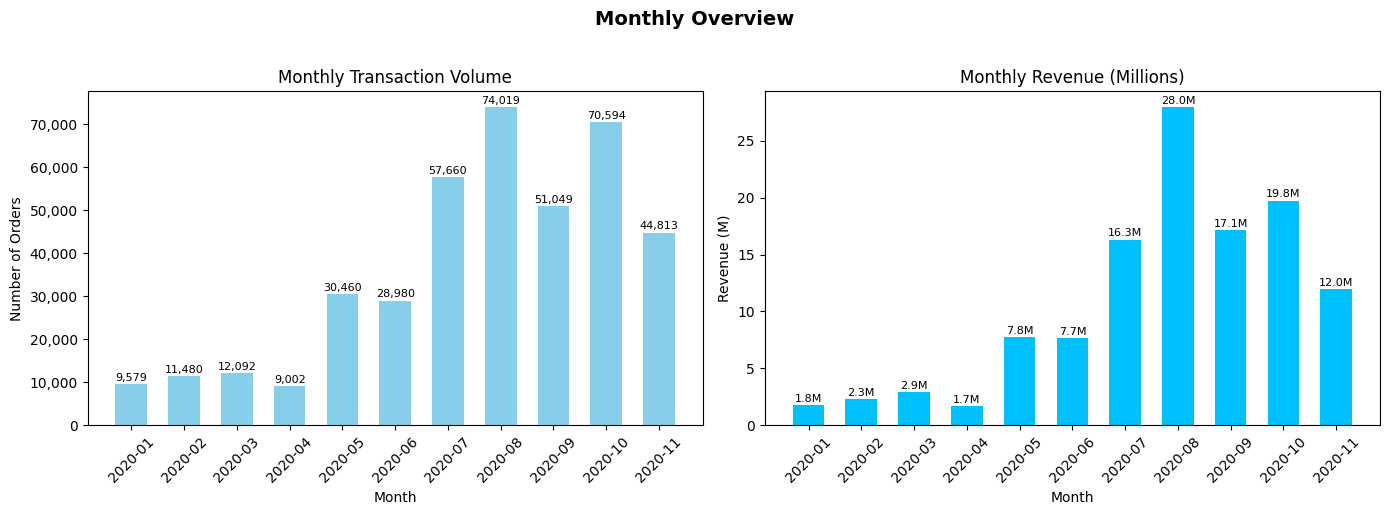

Monthly Summary:
year_month  orders  users  revenue(M)  avg_price
   2020-01    9579   1876        1.77 124.366901
   2020-02   11480   2321        2.27 126.059471
   2020-03   12092   2657        2.90 155.053581
   2020-04    9002   5605        1.70 143.379323
   2020-05   30460  17856        7.76 192.736669
   2020-06   28980  14370        7.69 186.077923
   2020-07   57660  31150       16.32 214.088335
   2020-08   74019  36564       27.96 279.927950
   2020-09   51049  20412       17.14 243.336894
   2020-10   70594  15051       19.75 190.064722
   2020-11   44813   8910       11.95 177.582069


In [24]:
monthly = (
    df_retail.groupby('year_month')
    .agg(
        orders    = ('order_id', 'nunique'),
        users     = ('user_id',  'nunique'),
        revenue   = ('price',    'sum'),
        avg_price = ('price',    'mean')
    )
    .reset_index()
)
months = monthly['year_month'].astype(str).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Orders per month ---
bars0 = axes[0].bar(months, monthly['orders'], color='skyblue', width=0.6)
axes[0].set_title('Monthly Transaction Volume')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, v in zip(bars0, monthly['orders']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + monthly['orders'].max() * 0.01,
                 f'{v:,}', ha='center', fontsize=8)

# --- Plot 2: Revenue per month ---
bars1 = axes[1].bar(months, monthly['revenue'] / 1e6, color='deepskyblue', width=0.6)
axes[1].set_title('Monthly Revenue (Millions)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue (M)')
axes[1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars1, monthly['revenue'] / 1e6):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + monthly['revenue'].max()/1e6 * 0.01,
                 f'{v:.1f}M', ha='center', fontsize=8)

plt.suptitle('Monthly Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Monthly Summary:')
monthly['revenue_M'] = (monthly['revenue'] / 1e6).round(2)
print(monthly[['year_month','orders','users','revenue_M','avg_price']]
      .rename(columns={'revenue_M':'revenue(M)','avg_price':'avg_price'})
      .to_string(index=False))

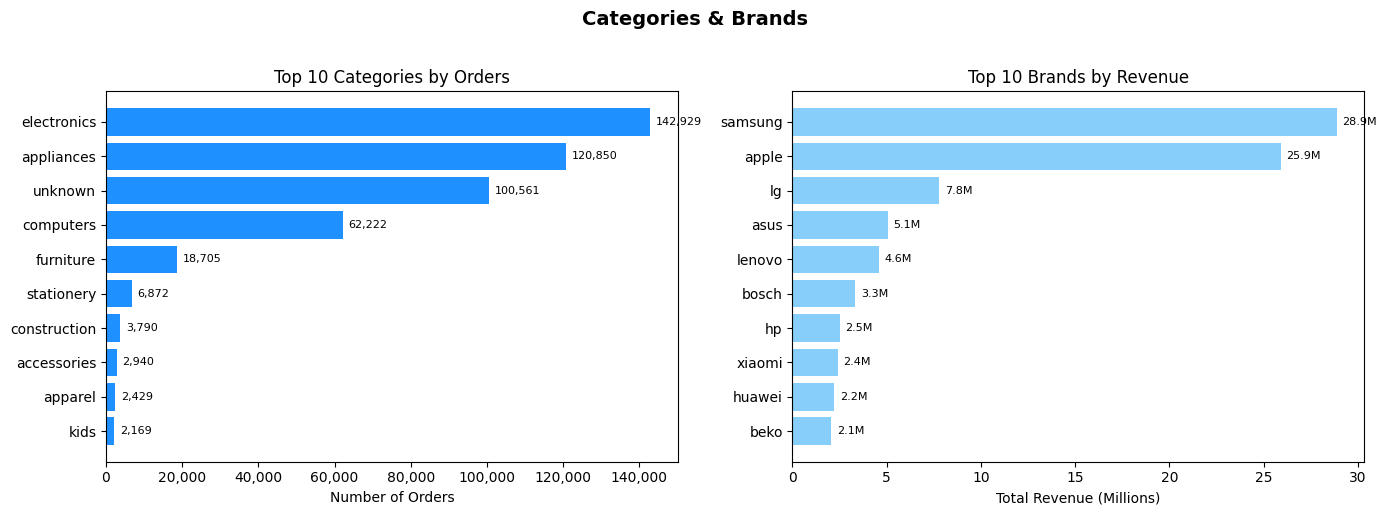

In [25]:
top_cats = (
    df_retail.groupby('category_top')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)

top_brands = (
    df_retail[df_retail['brand'] != 'unknown']
    .groupby('brand')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Top categories ---
axes[0].barh(top_cats['category_top'][::-1],
             top_cats['orders'][::-1], color='dodgerblue')
axes[0].set_title('Top 10 Categories by Orders')
axes[0].set_xlabel('Number of Orders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(top_cats['orders'][::-1]):
    axes[0].text(v + top_cats['orders'].max()*0.01, i,
                 f'{v:,}', va='center', fontsize=8)

# --- Top brands ---
axes[1].barh(top_brands['brand'][::-1],
             top_brands['price'][::-1] / 1e6, color='lightskyblue')
axes[1].set_title('Top 10 Brands by Revenue')
axes[1].set_xlabel('Total Revenue (Millions)')
for i, v in enumerate(top_brands['price'][::-1] / 1e6):
    axes[1].text(v + top_brands['price'].max()/1e6*0.01, i,
                 f'{v:.1f}M', va='center', fontsize=8)

plt.suptitle('Categories & Brands', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

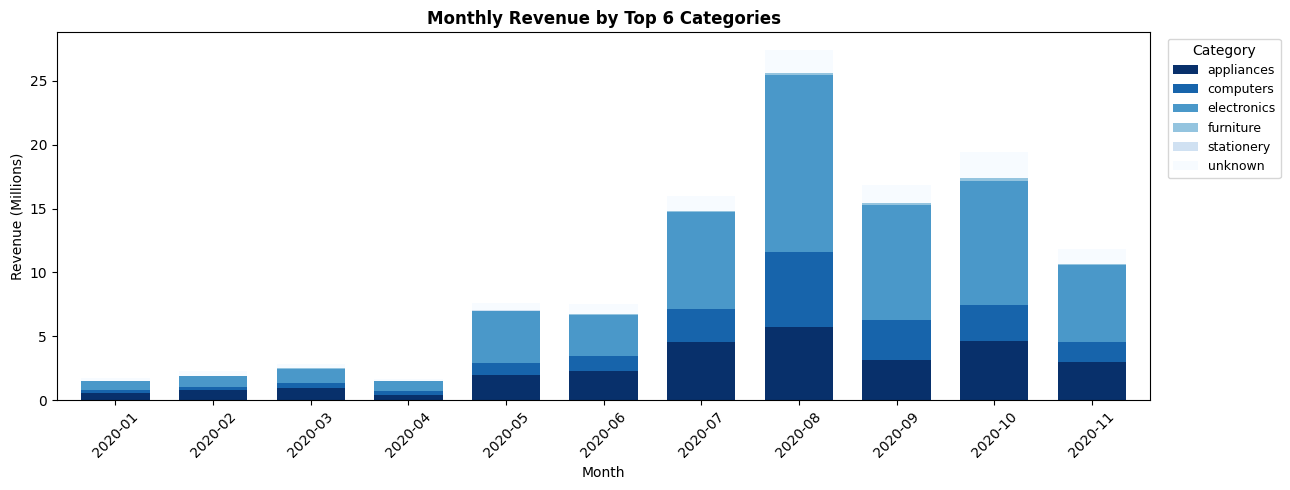

In [26]:
top6_cats = top_cats['category_top'].head(6).tolist()

cat_monthly = (
    df_retail[df_retail['category_top'].isin(top6_cats)]
    .groupby(['year_month', 'category_top'])['price']
    .sum()
    .unstack(fill_value=0)
    .div(1e6)  # convert to millions
)
cat_monthly.index = cat_monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
cat_monthly.plot(kind='bar', stacked=True, ax=ax,
                 colormap='Blues_r', width=0.7)
ax.set_title('Monthly Revenue by Top 6 Categories', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Millions)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

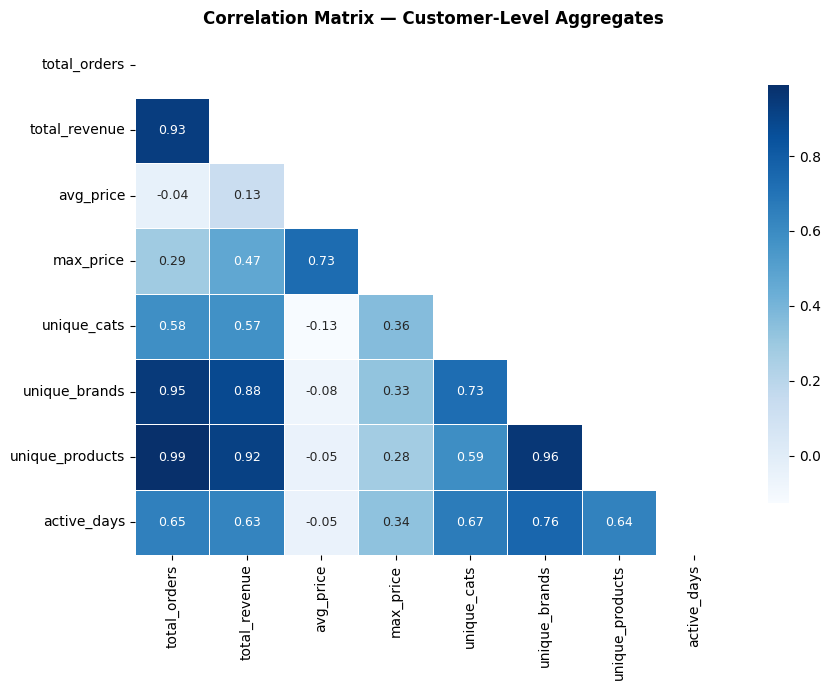

High correlations (|r| > 0.5):
  total_orders         ↔ total_revenue        : r = 0.932
  total_orders         ↔ unique_cats          : r = 0.581
  total_orders         ↔ unique_brands        : r = 0.946
  total_orders         ↔ unique_products      : r = 0.991
  total_orders         ↔ active_days          : r = 0.650
  total_revenue        ↔ unique_cats          : r = 0.573
  total_revenue        ↔ unique_brands        : r = 0.883
  total_revenue        ↔ unique_products      : r = 0.918
  total_revenue        ↔ active_days          : r = 0.629
  avg_price            ↔ max_price            : r = 0.732
  unique_cats          ↔ unique_brands        : r = 0.726
  unique_cats          ↔ unique_products      : r = 0.589
  unique_cats          ↔ active_days          : r = 0.666
  unique_brands        ↔ unique_products      : r = 0.958
  unique_brands        ↔ active_days          : r = 0.757
  unique_products      ↔ active_days          : r = 0.640


In [27]:
user_agg = df_retail.groupby('user_id').agg(
    total_orders   = ('order_id',    'nunique'),
    total_revenue  = ('price',       'sum'),
    avg_price      = ('price',       'mean'),
    max_price      = ('price',       'max'),
    unique_cats    = ('category_top','nunique'),
    unique_brands  = ('brand',       'nunique'),
    unique_products= ('product_id',  'nunique'),
    active_days    = ('date',        'nunique')
).reset_index()

corr_cols = ['total_orders','total_revenue','avg_price','max_price',
             'unique_cats','unique_brands','unique_products','active_days']
corr = user_agg[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='Blues',
    mask=mask, ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Customer-Level Aggregates', fontweight='bold')
plt.tight_layout()
plt.show()

# Print high correlations (> 0.5)
print('High correlations (|r| > 0.5):')
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_cols[i]:20} ↔ {corr_cols[j]:20} : r = {r:.3f}')

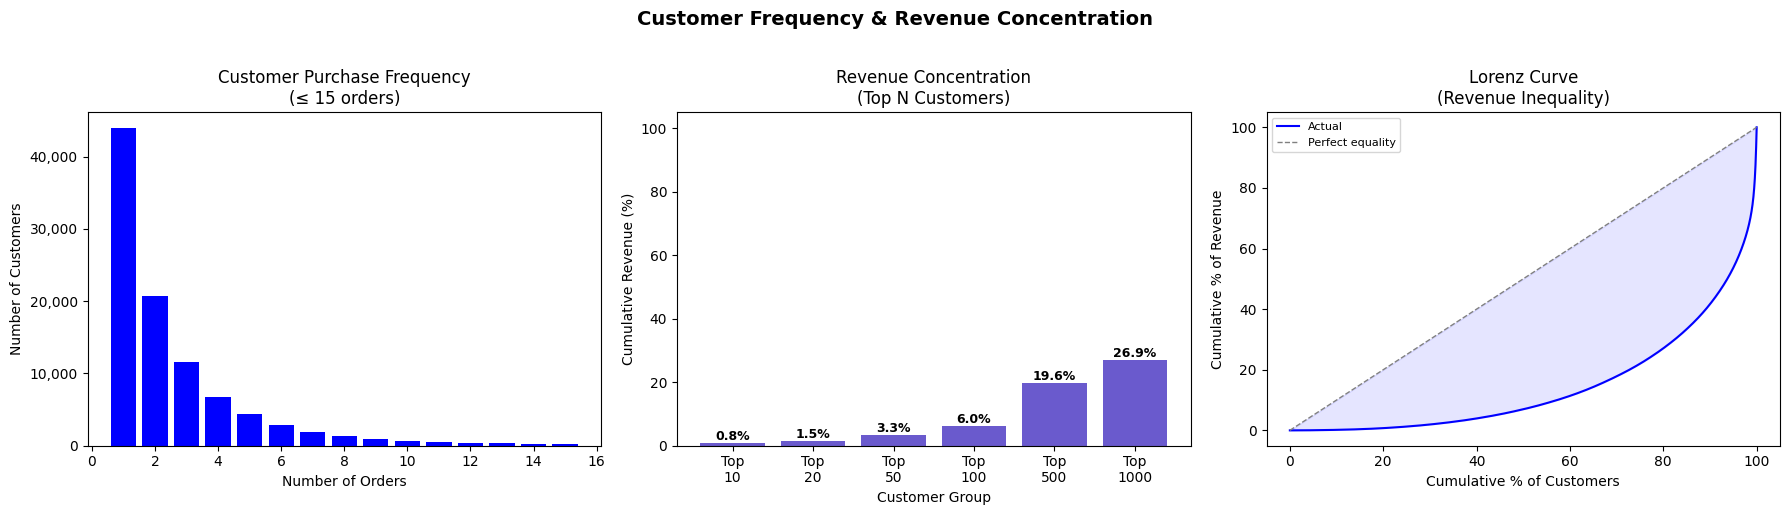

Customer Summary:
  Total customers  : 98,239
  One-time buyers  : 43,982  (44.8%)
  Repeat buyers    : 54,257  (55.2%)
  3+ orders        : 33,540
  Avg orders/user  : 4.07
  Max orders/user  : 402


In [28]:
orders_per_user = df_retail.groupby('user_id')['order_id'].nunique()
user_revenue    = df_retail.groupby('user_id')['price'].sum().sort_values(ascending=False)

# Frequency distribution (capped at 15)
freq_dist = orders_per_user.value_counts().sort_index()
freq_cap  = freq_dist[freq_dist.index <= 15]

# Cumulative revenue by top N customers
cumrev   = user_revenue.cumsum() / user_revenue.sum() * 100
top_n    = [10, 20, 50, 100, 500, 1000]
top_vals = [round(cumrev.iloc[n-1], 1) if n <= len(cumrev) else 100.0 for n in top_n]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Purchase frequency bar
axes[0].bar(freq_cap.index, freq_cap.values, color='blue')
axes[0].set_title('Customer Purchase Frequency\n(≤ 15 orders)')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Revenue concentration bar
axes[1].bar([f'Top\n{n}' for n in top_n], top_vals, color='slateblue')
axes[1].set_title('Revenue Concentration\n(Top N Customers)')
axes[1].set_xlabel('Customer Group')
axes[1].set_ylabel('Cumulative Revenue (%)')
axes[1].set_ylim(0, 105)
for i, v in enumerate(top_vals):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Lorenz curve
n_users   = len(user_revenue)
x_vals    = np.linspace(0, 100, n_users)
y_vals    = user_revenue[::-1].cumsum() / user_revenue.sum() * 100
axes[2].plot(x_vals, y_vals.values, color='blue', linewidth=1.5, label='Actual')
axes[2].plot([0, 100], [0, 100], color='gray', linestyle='--', linewidth=1, label='Perfect equality')
axes[2].fill_between(x_vals, y_vals.values, x_vals, alpha=0.1, color='blue')
axes[2].set_title('Lorenz Curve\n(Revenue Inequality)')
axes[2].set_xlabel('Cumulative % of Customers')
axes[2].set_ylabel('Cumulative % of Revenue')
axes[2].legend(fontsize=8)

plt.suptitle('Customer Frequency & Revenue Concentration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Customer Summary:')
print(f'  Total customers  : {len(orders_per_user):,}')
print(f'  One-time buyers  : {(orders_per_user == 1).sum():,}  ({(orders_per_user == 1).mean()*100:.1f}%)')
print(f'  Repeat buyers    : {(orders_per_user > 1).sum():,}  ({(orders_per_user > 1).mean()*100:.1f}%)')
print(f'  3+ orders        : {(orders_per_user >= 3).sum():,}')
print(f'  Avg orders/user  : {orders_per_user.mean():.2f}')
print(f'  Max orders/user  : {orders_per_user.max()}')

##Feature Engineering

---
### Pipeline:
```
1. Load & Time Window Split
   └── Training : Jan–Aug 2020  (sumber semua fitur)
   └── Observation: Sep–Nov 2020 (sumber label & target)

2. RFM Features
   └── Recency, Frequency, Monetary
   └── R/F/M score (quintile 1–5)
   └── RFM segment (Champions → Lost)

3. Behavioral Features (10 fitur)
   └── active_days, unique_categories, unique_brands
   └── unique_products, avg/max/std order value
   └── total_items, customer_lifetime_days
   └── avg_purchase_interval

4. Churn Label
   └── 1 = tidak beli sama sekali di Sep–Nov 2020
   └── 0 = masih beli di Sep–Nov 2020

5. Purchase Behavior Target
   └── total revenue customer di Sep–Nov 2020

6. Merge & Export
```
---

In [29]:
df_retail['event_time'] = pd.to_datetime(df_retail['event_time'], utc=True)
df_retail['date']       = pd.to_datetime(df_retail['date']).dt.date

# ── Definisi time window ─────────────────────────────────────
TRAIN_END = pd.Timestamp('2020-08-31 23:59:59', tz='UTC')
OBS_START = pd.Timestamp('2020-09-01 00:00:00', tz='UTC')
OBS_END   = pd.Timestamp('2020-11-30 23:59:59', tz='UTC')
SNAPSHOT  = TRAIN_END   # reference date untuk hitung Recency

df_train = df_retail[df_retail['event_time'] <= TRAIN_END].copy()
df_obs   = df_retail[
    (df_retail['event_time'] >= OBS_START) &
    (df_retail['event_time'] <= OBS_END)
].copy()

print('='*55)
print('TIME WINDOW SPLIT')
print('='*55)
print(f'  Training window  : {df_train["event_time"].min().date()}  →  {df_train["event_time"].max().date()}')
print(f'  Training rows    : {len(df_train):,}')
print(f'  Training users   : {df_train["user_id"].nunique():,}')
print(f'  Observation win  : {df_obs["event_time"].min().date()}  →  {df_obs["event_time"].max().date()}')
print(f'  Observation rows : {len(df_obs):,}')
print(f'  Observation users: {df_obs["user_id"].nunique():,}')

TIME WINDOW SPLIT
  Training window  : 2020-01-05  →  2020-08-31
  Training rows    : 320,493
  Training users   : 80,175
  Observation win  : 2020-09-01  →  2020-11-21
  Observation rows : 241,656
  Observation users: 34,942


#RFM Features

In [30]:
# ── Hitung Recency, Frequency, Monetary ─────────────────────
rfm = df_train.groupby('user_id').agg(
    last_purchase = ('event_time', 'max'),
    frequency     = ('order_id',   'nunique'),
    monetary      = ('price',      'sum')
).reset_index()

rfm['recency'] = (SNAPSHOT - rfm['last_purchase']).dt.days
rfm.drop(columns=['last_purchase'], inplace=True)

# ── Quintile scoring 1–5 ─────────────────────────────────────
# Recency: hari lebih kecil = lebih bagus → skor terbalik
rfm['R_score'] = pd.qcut(rfm['recency'],
                          q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# ── Segmentasi ───────────────────────────────────────────────
def rfm_segment(score):
    if score >= 13:  return 'Champions'
    elif score >= 10: return 'Loyal'
    elif score >= 7:  return 'Potential Loyal'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['RFM_segment'] = rfm['RFM_score'].apply(rfm_segment)

print(f'RFM computed for {len(rfm):,} customers')
print('\nRFM descriptive stats:')
print(rfm[['recency','frequency','monetary']].describe().round(2))

RFM computed for 80,175 customers

RFM descriptive stats:
        recency  frequency  monetary
count  80175.00   80175.00  80175.00
mean      46.09       2.91    852.75
std       38.53       8.96   2167.66
min        0.00       1.00      0.02
25%       18.00       1.00    115.72
50%       34.00       1.00    351.81
75%       66.00       3.00    879.56
max      239.00     256.00  66697.53


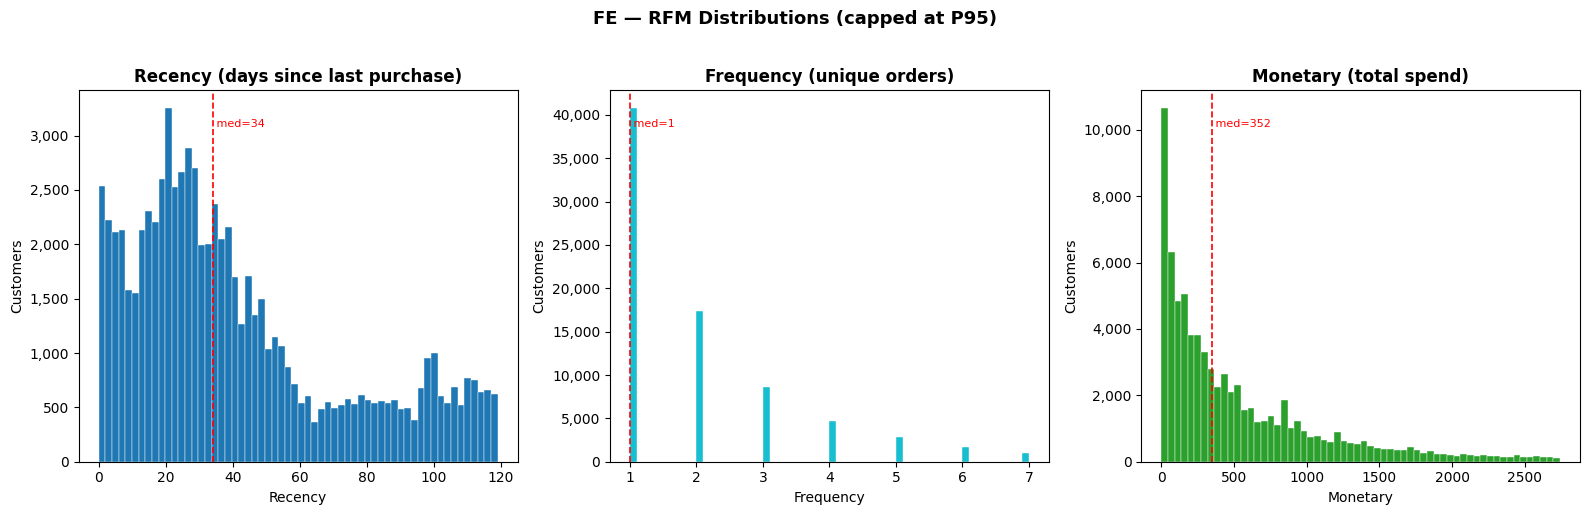

In [31]:
# ── Visualisasi RFM Distributions ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title, color in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    ['Recency (days since last purchase)',
     'Frequency (unique orders)',
     'Monetary (total spend)'],
    ['#1f77b4', '#17becf', '#2ca02c']
):
    cap  = rfm[col].quantile(0.95)
    data = rfm[rfm[col] <= cap][col]
    ax.hist(data, bins=60, color=color, edgecolor='white', linewidth=0.3)
    med = rfm[col].median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1.2)
    ax.text(med, ax.get_ylim()[1]*0.9, f' med={med:.0f}',
            color='red', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Customers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('FE — RFM Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

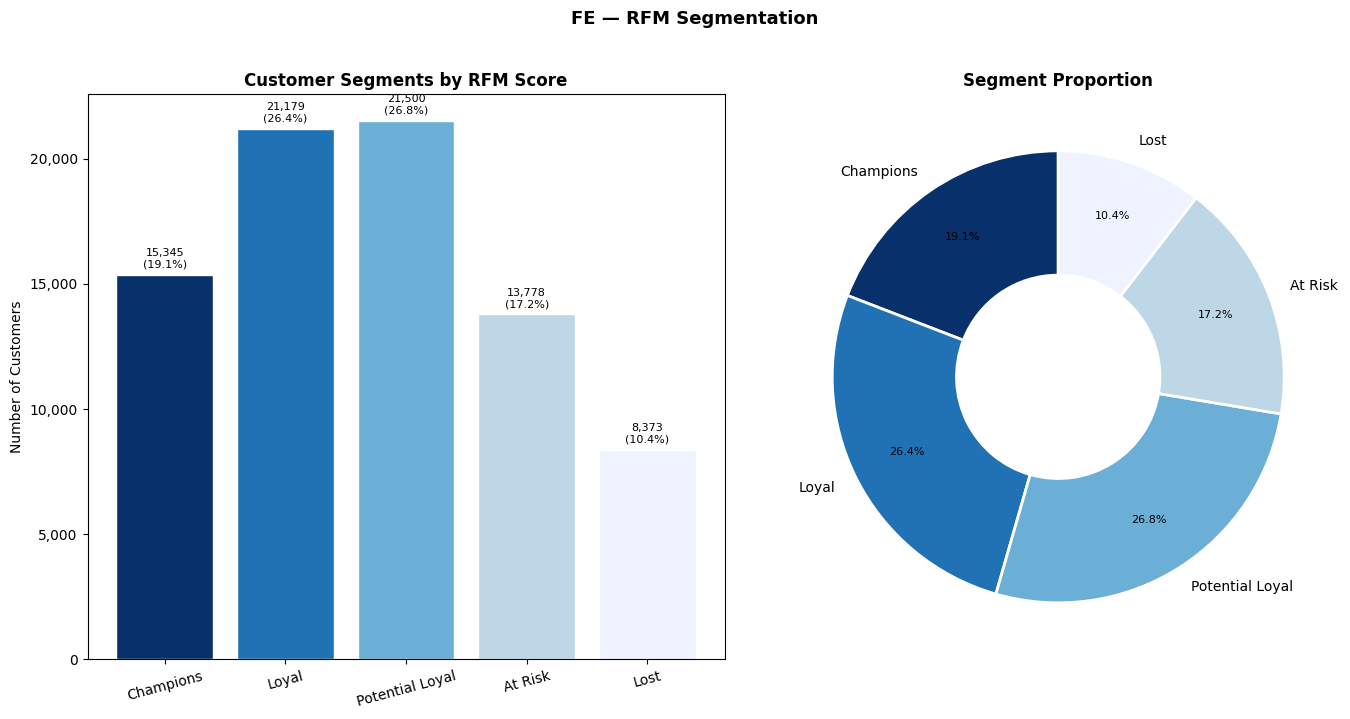


Segment Distribution:
  Champions         :  15,345  (19.1%)
  Loyal             :  21,179  (26.4%)
  Potential Loyal   :  21,500  (26.8%)
  At Risk           :  13,778  (17.2%)
  Lost              :   8,373  (10.4%)


In [32]:
# ── Visualisasi RFM Segments ─────────────────────────────────
SEG_ORDER  = ['Champions', 'Loyal', 'Potential Loyal', 'At Risk', 'Lost']
SEG_COLORS = ['#08306b', '#2171b5', '#6baed6', '#bdd7e7', '#eff3ff']

seg_counts = rfm['RFM_segment'].value_counts().reindex(SEG_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Bar chart dengan label count + persen
bars = axes[0].bar(SEG_ORDER, seg_counts.values,
                   color=SEG_COLORS, edgecolor='white', linewidth=1)
axes[0].set_title('Customer Segments by RFM Score', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, cnt in zip(bars, seg_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        cnt + seg_counts.max()*0.01,
        f'{cnt:,}\n({cnt/len(rfm)*100:.1f}%)',
        ha='center', va='bottom', fontsize=8
    )

# Donut chart proporsi segmen
wedges, texts, autotexts = axes[1].pie(
    seg_counts.values,
    labels=SEG_ORDER,
    colors=SEG_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(8)
axes[1].set_title('Segment Proportion', fontweight='bold')

plt.suptitle('FE — RFM Segmentation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nSegment Distribution:')
for seg in SEG_ORDER:
    cnt = seg_counts[seg]
    print(f'  {seg:<18}: {cnt:>7,}  ({cnt/len(rfm)*100:.1f}%)')

### Behavioral Features

In [33]:
# ── 10 behavioral features dari training window ──────────────
behavioral = df_train.groupby('user_id').agg(
    active_days       = ('date',         'nunique'),
    unique_categories = ('category_top', 'nunique'),
    unique_brands     = ('brand',        'nunique'),
    unique_products   = ('product_id',   'nunique'),
    avg_order_value   = ('price',        'mean'),
    max_order_value   = ('price',        'max'),
    std_order_value   = ('price',        'std'),
    total_items       = ('product_id',   'count'),
    first_purchase    = ('event_time',   'min'),
    last_purchase_ts  = ('event_time',   'max'),
).reset_index()

# Lifetime: hari dari pembelian pertama ke terakhir
behavioral['customer_lifetime_days'] = (
    behavioral['last_purchase_ts'] - behavioral['first_purchase']
).dt.days

# Rata-rata jarak antar hari aktif
behavioral['avg_purchase_interval'] = (
    behavioral['customer_lifetime_days'] /
    behavioral['active_days'].clip(lower=1)
).round(2)

# std = NaN untuk user 1 transaksi → isi 0
behavioral['std_order_value'] = behavioral['std_order_value'].fillna(0)

behavioral.drop(columns=['first_purchase', 'last_purchase_ts'], inplace=True)

print(f'Behavioral features: {behavioral.shape[1]-1} fitur untuk {len(behavioral):,} customers')
print('\nFeatures:')
for col in behavioral.columns[1:]:
    print(f'  - {col:<30} | median: {behavioral[col].median():.2f}')

Behavioral features: 10 fitur untuk 80,175 customers

Features:
  - active_days                    | median: 1.00
  - unique_categories              | median: 1.00
  - unique_brands                  | median: 1.00
  - unique_products                | median: 2.00
  - avg_order_value                | median: 173.58
  - max_order_value                | median: 254.61
  - std_order_value                | median: 3.27
  - total_items                    | median: 2.00
  - customer_lifetime_days         | median: 0.00
  - avg_purchase_interval          | median: 0.00


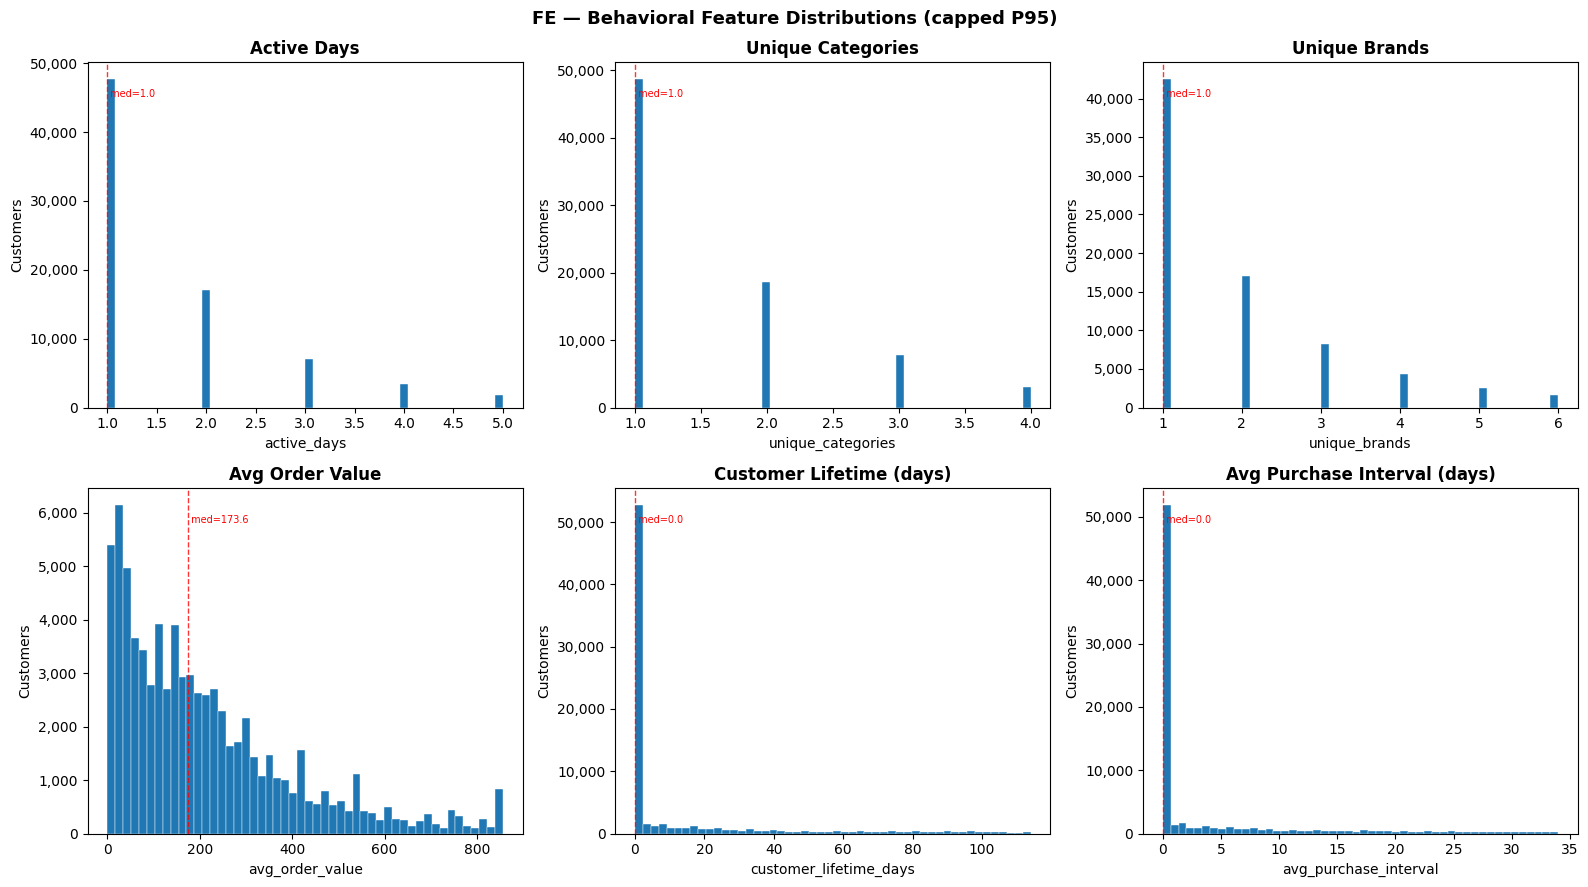

In [34]:
# ── Visualisasi distribusi 6 behavioral features utama ───────
feat_plot = ['active_days', 'unique_categories', 'unique_brands',
             'avg_order_value', 'customer_lifetime_days', 'avg_purchase_interval']
titles = ['Active Days', 'Unique Categories', 'Unique Brands',
          'Avg Order Value', 'Customer Lifetime (days)', 'Avg Purchase Interval (days)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col, title in zip(axes, feat_plot, titles):
    cap  = behavioral[col].quantile(0.95)
    data = behavioral[behavioral[col] <= cap][col]
    ax.hist(data, bins=50, color='#1f77b4', edgecolor='white', linewidth=0.3)
    med = behavioral[col].median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1, alpha=0.8)
    ax.text(med, ax.get_ylim()[1]*0.9, f' med={med:.1f}', color='red', fontsize=7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Customers')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('FE — Behavioral Feature Distributions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###Churn Label

In [35]:
# ── Buat churn label ─────────────────────────────────────────
obs_buyers  = set(df_obs['user_id'].unique())
train_users = rfm['user_id'].tolist()

churn_df = pd.DataFrame({'user_id': train_users})
churn_df['churned'] = churn_df['user_id'].apply(
    lambda uid: 0 if uid in obs_buyers else 1
)

n_churned  = churn_df['churned'].sum()
n_retained = len(churn_df) - n_churned
churn_rate = n_churned / len(churn_df)

print('='*55)
print('CHURN LABEL SUMMARY')
print('='*55)
print(f'  Total customers    : {len(churn_df):,}')
print(f'  Churned  (label=1) : {n_churned:,}  ({churn_rate*100:.1f}%)')
print(f'  Retained (label=0) : {n_retained:,}  ({(1-churn_rate)*100:.1f}%)')
print(f'  Imbalance ratio    : 1 : {n_retained/n_churned:.2f}  (churned : retained)')

CHURN LABEL SUMMARY
  Total customers    : 80,175
  Churned  (label=1) : 63,297  (78.9%)
  Retained (label=0) : 16,878  (21.1%)
  Imbalance ratio    : 1 : 0.27  (churned : retained)


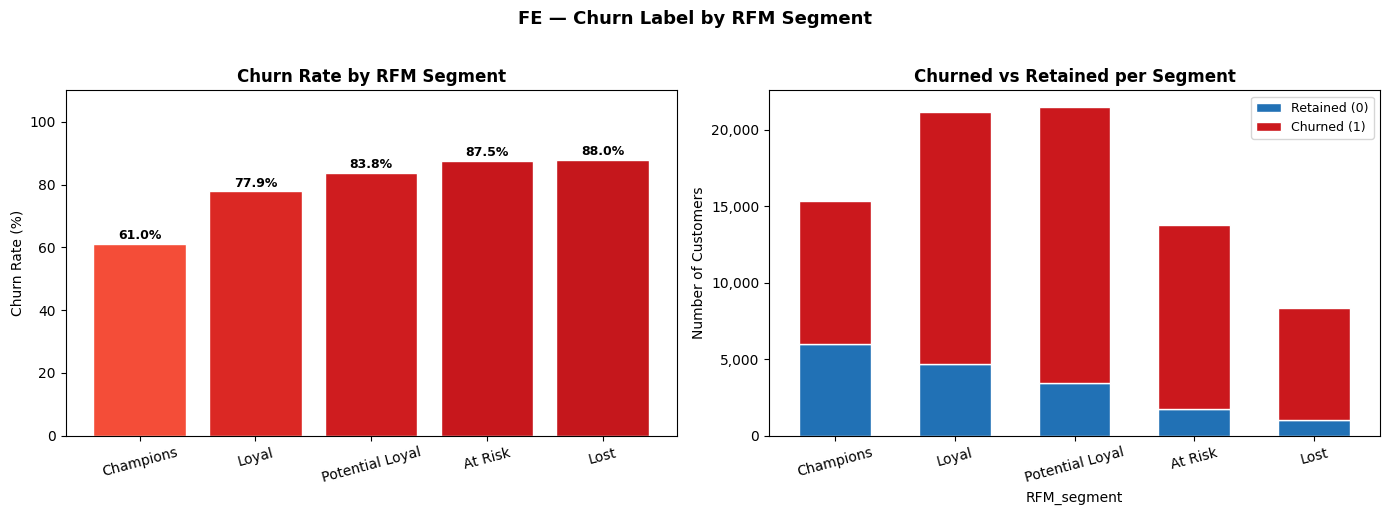


Churn rate per segment:
  Champions         : 61.0%  (n=15,345)
  Loyal             : 77.9%  (n=21,179)
  Potential Loyal   : 83.8%  (n=21,500)
  At Risk           : 87.5%  (n=13,778)
  Lost              : 88.0%  (n=8,373)


In [36]:
# ── Visualisasi churn per RFM segment ────────────────────────
churn_rfm = rfm[['user_id','RFM_segment']].merge(churn_df, on='user_id')

churn_by_seg = (
    churn_rfm.groupby('RFM_segment')['churned']
    .agg(['mean','count'])
    .reindex(SEG_ORDER)
    .reset_index()
)
churn_by_seg.columns = ['segment','churn_rate','count']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate per segment — warna berdasarkan nilai (merah = tinggi)
from matplotlib.colors import Normalize
from matplotlib import cm
cmap_r     = cm.get_cmap('Reds')
norm_c     = Normalize(vmin=0, vmax=1)
colors_seg = [cmap_r(norm_c(v)*0.7+0.15) for v in churn_by_seg['churn_rate']]

bars = axes[0].bar(churn_by_seg['segment'],
                   churn_by_seg['churn_rate']*100,
                   color=colors_seg, edgecolor='white')
axes[0].set_title('Churn Rate by RFM Segment', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, churn_by_seg['churn_rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 v*100+1.5, f'{v*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Stacked bar: retained vs churned
churn_counts = (
    churn_rfm.groupby(['RFM_segment','churned'])
    .size().unstack(fill_value=0)
    .reindex(SEG_ORDER)
)
churn_counts.plot(kind='bar', stacked=True, ax=axes[1],
                  color=['#2171b5','#cb181d'],
                  edgecolor='white', width=0.6)
axes[1].set_title('Churned vs Retained per Segment', fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Retained (0)','Churned (1)'], fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('FE — Churn Label by RFM Segment', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nChurn rate per segment:')
for _, row in churn_by_seg.iterrows():
    print(f"  {row['segment']:<18}: {row['churn_rate']*100:.1f}%  (n={int(row['count']):,})")

###Purchase Behavior Target

PURCHASE BEHAVIOR TARGET SUMMARY
  Users with revenue > 0 : 16,878
  Users with revenue = 0 : 63,297
  Mean target revenue    : 205.52
  Median target revenue  : 0.00
  Max target revenue     : 74,523.21


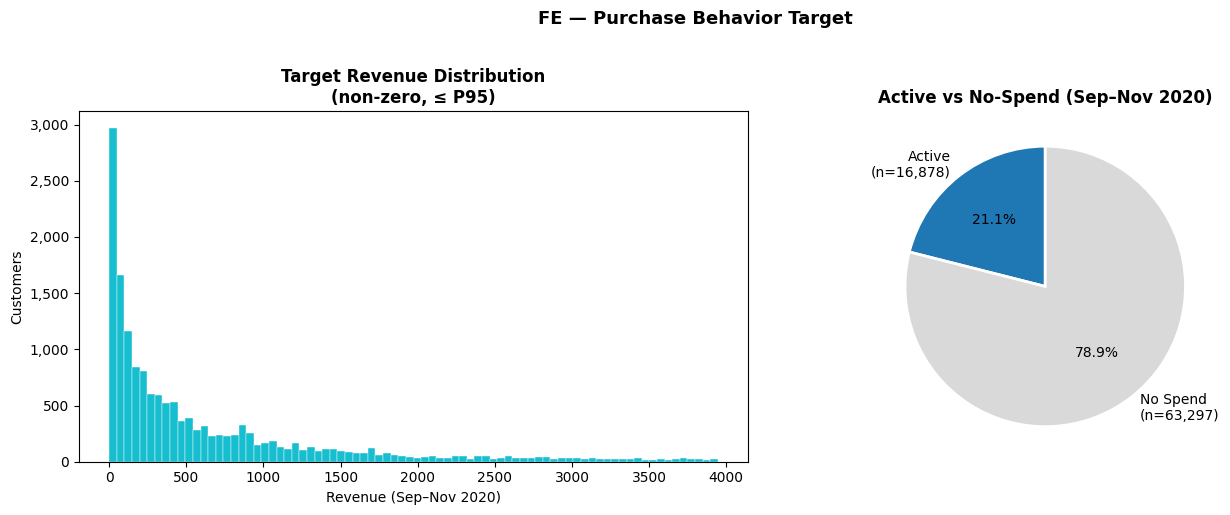

In [37]:
# ── Target: total revenue per customer di Sep–Nov 2020 ───────
obs_revenue = (
    df_obs.groupby('user_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price':'target_revenue'})
)

purchase_target = (
    pd.DataFrame({'user_id': train_users})
    .merge(obs_revenue, on='user_id', how='left')
)
purchase_target['target_revenue'] = purchase_target['target_revenue'].fillna(0)

nonzero = purchase_target[purchase_target['target_revenue'] > 0]['target_revenue']

print('='*55)
print('PURCHASE BEHAVIOR TARGET SUMMARY')
print('='*55)
print(f'  Users with revenue > 0 : {len(nonzero):,}')
print(f'  Users with revenue = 0 : {(purchase_target["target_revenue"]==0).sum():,}')
print(f'  Mean target revenue    : {purchase_target["target_revenue"].mean():,.2f}')
print(f'  Median target revenue  : {purchase_target["target_revenue"].median():,.2f}')
print(f'  Max target revenue     : {purchase_target["target_revenue"].max():,.2f}')

# Visualisasi
p95_rev = nonzero.quantile(0.95)
zero_cnt    = (purchase_target['target_revenue'] == 0).sum()
nonzero_cnt = len(nonzero)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(nonzero[nonzero <= p95_rev], bins=80,
             color='#17becf', edgecolor='white', linewidth=0.3)
axes[0].set_title('Target Revenue Distribution\n(non-zero, ≤ P95)', fontweight='bold')
axes[0].set_xlabel('Revenue (Sep–Nov 2020)')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].pie(
    [nonzero_cnt, zero_cnt],
    labels=[f'Active\n(n={nonzero_cnt:,})', f'No Spend\n(n={zero_cnt:,})'],
    colors=['#1f77b4','#d9d9d9'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Active vs No-Spend (Sep–Nov 2020)', fontweight='bold')

plt.suptitle('FE — Purchase Behavior Target', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

###Merge & Export Final Feature Matrix

In [38]:
# ── Merge semua tabel ────────────────────────────────────────
rfm_cols = ['user_id','recency','frequency','monetary',
            'R_score','F_score','M_score','RFM_score','RFM_segment']

df_final = (
    rfm[rfm_cols]
    .merge(behavioral,      on='user_id', how='left')
    .merge(churn_df,        on='user_id', how='left')
    .merge(purchase_target, on='user_id', how='left')
)

print('='*55)
print('FINAL FEATURE MATRIX')
print('='*55)
print(f'  Shape      : {df_final.shape[0]:,} rows × {df_final.shape[1]} columns')
print(f'  Features   : {df_final.shape[1]-3}  (exclude user_id, churned, target_revenue)')
print(f'  Null count : {df_final.isnull().sum().sum()}')
print(f'\nAll columns:')
for i, col in enumerate(df_final.columns, 1):
    dtype = str(df_final[col].dtype)
    null  = df_final[col].isnull().sum()
    print(f'  {i:2}. {col:<28} [{dtype}]  nulls: {null}')

FINAL FEATURE MATRIX
  Shape      : 80,175 rows × 21 columns
  Features   : 18  (exclude user_id, churned, target_revenue)
  Null count : 0

All columns:
   1. user_id                      [int64]  nulls: 0
   2. recency                      [int64]  nulls: 0
   3. frequency                    [int64]  nulls: 0
   4. monetary                     [float64]  nulls: 0
   5. R_score                      [int64]  nulls: 0
   6. F_score                      [int64]  nulls: 0
   7. M_score                      [int64]  nulls: 0
   8. RFM_score                    [int64]  nulls: 0
   9. RFM_segment                  [object]  nulls: 0
  10. active_days                  [int64]  nulls: 0
  11. unique_categories            [int64]  nulls: 0
  12. unique_brands                [int64]  nulls: 0
  13. unique_products              [int64]  nulls: 0
  14. avg_order_value              [float64]  nulls: 0
  15. max_order_value              [float64]  nulls: 0
  16. std_order_value              [float64]

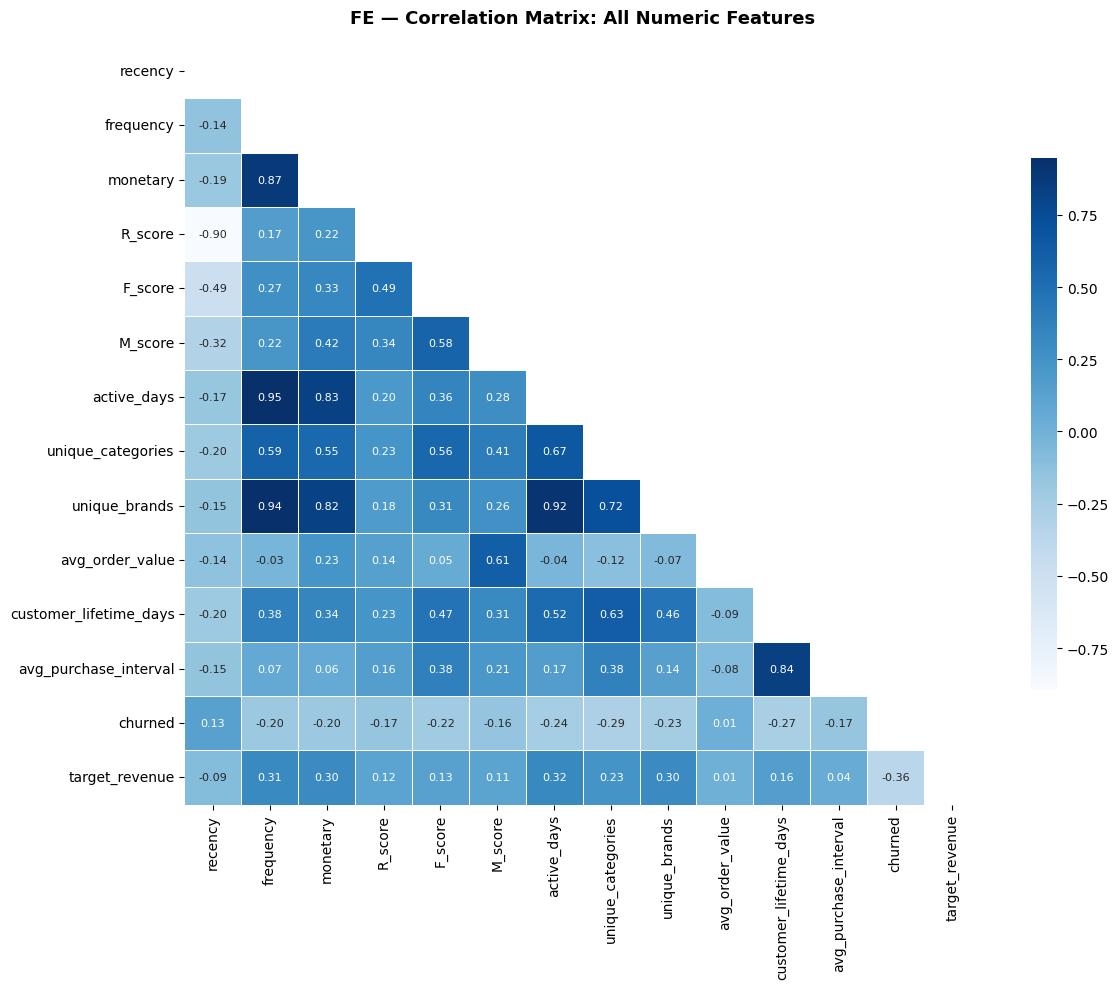

Top fitur berkorelasi dengan CHURN (|r| > 0.05):
  target_revenue                 r = -0.359
  unique_categories              r = -0.285
  customer_lifetime_days         r = -0.266
  active_days                    r = -0.243
  unique_brands                  r = -0.235
  F_score                        r = -0.217
  frequency                      r = -0.198
  monetary                       r = -0.197
  avg_purchase_interval          r = -0.169
  R_score                        r = -0.167
  M_score                        r = -0.160
  recency                        r = +0.129

Top fitur berkorelasi dengan TARGET REVENUE (|r| > 0.05):
  churned                        r = -0.359
  active_days                    r = +0.319
  frequency                      r = +0.308
  monetary                       r = +0.303
  unique_brands                  r = +0.303
  unique_categories              r = +0.234
  customer_lifetime_days         r = +0.155
  F_score                        r = +0.128
  R_score   

In [39]:
# ── Correlation heatmap seluruh fitur numerik ────────────────
num_cols = ['recency','frequency','monetary',
            'R_score','F_score','M_score',
            'active_days','unique_categories','unique_brands',
            'avg_order_value','customer_lifetime_days',
            'avg_purchase_interval','churned','target_revenue']

corr = df_final[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            mask=mask, ax=ax, linewidths=0.4,
            cbar_kws={'shrink':0.7}, annot_kws={'size':8})
ax.set_title('FE — Correlation Matrix: All Numeric Features',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top features korelasi dengan churn & target
print('Top fitur berkorelasi dengan CHURN (|r| > 0.05):')
churn_corr = corr['churned'].drop('churned').abs().sort_values(ascending=False)
for feat, r in churn_corr[churn_corr > 0.05].items():
    sign = '+' if corr.loc[feat,'churned'] > 0 else '-'
    print(f'  {feat:<30} r = {sign}{r:.3f}')

print('\nTop fitur berkorelasi dengan TARGET REVENUE (|r| > 0.05):')
target_corr = corr['target_revenue'].drop('target_revenue').abs().sort_values(ascending=False)
for feat, r in target_corr[target_corr > 0.05].items():
    sign = '+' if corr.loc[feat,'target_revenue'] > 0 else '-'
    print(f'  {feat:<30} r = {sign}{r:.3f}')

In [40]:
# ── Simpan ke Google Drive ───────────────────────────────────
# out_path = '/content/drive/MyDrive/Data/customer360_features.csv'
# df_final.to_csv(out_path, index=False)

In [41]:
# df_360=pd.read_csv('/content/drive/MyDrive/Data/customer360_features.csv')
# df_360

# Churn Prediction

In [42]:
# ── Install / import ─────────────────────────────────────────
!pip install lightgbm shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    ConfusionMatrixDisplay, average_precision_score, PrecisionRecallDisplay
)
from sklearn.pipeline        import Pipeline
from xgboost                 import XGBClassifier
import lightgbm              as lgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size'      : 10,
})

In [44]:
# ── Load feature matrix dari Google Drive ─────────────────────
DATA_PATH  = '/content/drive/MyDrive/Kuliah/Data/customer360_features.csv'
SAVE_PATH  = '/content/drive/MyDrive/Kuliah/Data/'   # folder output

df = pd.read_csv(DATA_PATH)

print('='*55)
print('FEATURE MATRIX LOADED')
print('='*55)
print(f'  Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Null     : {df.isnull().sum().sum()}')
print(f'  Churned  : {df["churned"].sum():,}  ({df["churned"].mean()*100:.1f}%)')
print(f'  Retained : {(df["churned"]==0).sum():,}  ({(df["churned"]==0).mean()*100:.1f}%)')
df.head(3)

FEATURE MATRIX LOADED
  Shape    : 80,175 rows × 21 columns
  Null     : 0
  Churned  : 63,297  (78.9%)
  Retained : 16,878  (21.1%)


,user_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_segment,active_days,...,unique_brands,unique_products,avg_order_value,max_order_value,std_order_value,total_items,customer_lifetime_days,avg_purchase_interval,churned,target_revenue
0,1515915625439952128,53,1,416.64,2,1,3,6,At Risk,1,...,1,1,416.640000,416.64,0.000000,1,0,0.0,1,0.00
1,1515915625440099840,47,6,2227.87,2,5,5,12,Loyal,5,...,5,6,371.311667,1144.65,445.478632,6,63,12.6,0,2707.73
2,1515915625440121600,48,2,182.83,2,3,2,7,Potential Loyal,2,...,1,2,91.415000,138.87,67.111505,2,58,29.0,1,0.00


In [45]:
# ── Definisi fitur untuk churn model ─────────────────────────
#    Exclude: user_id, RFM_segment (string → encode terpisah), target_revenue

NUMERIC_FEATURES = [
    # RFM
    'recency', 'frequency', 'monetary',
    'R_score', 'F_score', 'M_score', 'RFM_score',
    # Behavioral
    'active_days', 'unique_categories', 'unique_brands', 'unique_products',
    'avg_order_value', 'max_order_value', 'std_order_value',
    'total_items', 'customer_lifetime_days', 'avg_purchase_interval',
]

# Encode RFM_segment → ordinal (Champions=5 ... Lost=1)
SEG_ORDER = ['Champions', 'Loyal', 'Potential Loyal', 'At Risk', 'Lost']
seg_map   = {seg: (5-i) for i, seg in enumerate(SEG_ORDER)}
df['RFM_segment_enc'] = df['RFM_segment'].map(seg_map).astype(int)

ALL_FEATURES = NUMERIC_FEATURES + ['RFM_segment_enc']
TARGET       = 'churned'

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# ── Train-Test Split — stratified 80:20 ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Hitung scale_pos_weight untuk XGBoost (rasio majority:minority)
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'Train set : {X_train.shape[0]:,} samples  (churned={y_train.sum():,} | retained={(y_train==0).sum():,})')
print(f'Test set  : {X_test.shape[0]:,} samples  (churned={y_test.sum():,} | retained={(y_test==0).sum():,})')
print(f'scale_pos_weight (XGB) : {scale_pos_weight:.3f}')
print(f'Features used : {len(ALL_FEATURES)}')

Train set : 64,140 samples  (churned=50,638 | retained=13,502)
Test set  : 16,035 samples  (churned=12,659 | retained=3,376)
scale_pos_weight (XGB) : 0.267
Features used : 18


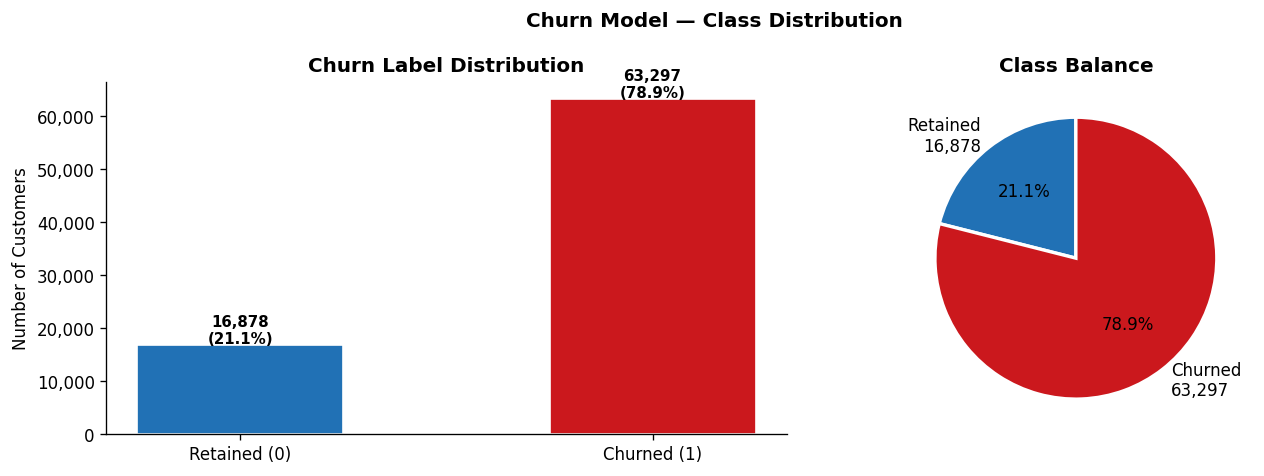

Imbalance ratio: 3.75:1  →  ⚠️ Significant imbalance


In [46]:
# ── Visualisasi Class Distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
counts = y.value_counts().sort_index()
bars   = axes[0].bar(['Retained (0)', 'Churned (1)'],
                     counts.values,
                     color=['#2171b5', '#cb181d'], edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+200,
                 f'{v:,}\n({v/len(y)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Churn Label Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pie
axes[1].pie(counts.values,
            labels=[f'Retained\n{counts[0]:,}', f'Churned\n{counts[1]:,}'],
            colors=['#2171b5', '#cb181d'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance', fontweight='bold')

plt.suptitle('Churn Model — Class Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance = counts.max() / counts.min()
print(f'Imbalance ratio: {imbalance:.2f}:1  →  {"⚠️ Significant imbalance" if imbalance > 3 else "✅ Mild imbalance"}')

In [47]:
# ── Logistic Regression (dengan scaling + class_weight) ───────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)

# Predict
y_pred_lr      = lr_pipeline.predict(X_test)
y_proba_lr     = lr_pipeline.predict_proba(X_test)[:, 1]

# Metrics
metrics_lr = {
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_lr),
    'F1-Score' : f1_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'PR-AUC'   : average_precision_score(y_test, y_proba_lr),
}

print('='*50)
print('BASELINE — Logistic Regression')
print('='*50)
for k, v in metrics_lr.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Retained','Churned']))

BASELINE — Logistic Regression
  ROC-AUC     : 0.6929
  F1-Score    : 0.8071
  Precision   : 0.8593
  Recall      : 0.7609
  PR-AUC      : 0.8704

              precision    recall  f1-score   support

    Retained       0.37      0.53      0.44      3376
     Churned       0.86      0.76      0.81     12659

    accuracy                           0.71     16035
   macro avg       0.62      0.65      0.62     16035
weighted avg       0.76      0.71      0.73     16035



In [48]:
# ── XGBoost — handle class imbalance via scale_pos_weight ─────
xgb_model = XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,   # handle imbalance
    eval_metric       = 'auc',
    early_stopping_rounds = 30,
    random_state      = SEED,
    verbosity         = 0,
    use_label_encoder = False,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predict
y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
metrics_xgb = {
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_xgb),
    'F1-Score' : f1_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'PR-AUC'   : average_precision_score(y_test, y_proba_xgb),
}

print('='*50)
print('XGBoost Classifier')
print('='*50)
for k, v in metrics_xgb.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Retained','Churned']))

XGBoost Classifier
  ROC-AUC     : 0.7084
  F1-Score    : 0.8071
  Precision   : 0.8623
  Recall      : 0.7585
  PR-AUC      : 0.8812

              precision    recall  f1-score   support

    Retained       0.38      0.55      0.45      3376
     Churned       0.86      0.76      0.81     12659

    accuracy                           0.71     16035
   macro avg       0.62      0.65      0.63     16035
weighted avg       0.76      0.71      0.73     16035



In [49]:
# ── LightGBM — is_unbalance=True sebagai alternatif ───────────
lgbm_model = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    is_unbalance      = True,   # handle class imbalance
    metric            = 'auc',
    random_state      = SEED,
    verbose           = -1,
)

# Callbacks untuk early stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=-1)
]

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=callbacks
)

# Predict
y_pred_lgbm  = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Metrics
metrics_lgbm = {
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_lgbm),
    'F1-Score' : f1_score(y_test, y_pred_lgbm),
    'Precision': precision_score(y_test, y_pred_lgbm),
    'Recall'   : recall_score(y_test, y_pred_lgbm),
    'PR-AUC'   : average_precision_score(y_test, y_proba_lgbm),
}

print('='*50)
print('LightGBM Classifier')
print('='*50)
for k, v in metrics_lgbm.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['Retained','Churned']))

LightGBM Classifier
  ROC-AUC     : 0.7075
  F1-Score    : 0.8171
  Precision   : 0.8605
  Recall      : 0.7779
  PR-AUC      : 0.8808

              precision    recall  f1-score   support

    Retained       0.39      0.53      0.45      3376
     Churned       0.86      0.78      0.82     12659

    accuracy                           0.73     16035
   macro avg       0.62      0.65      0.63     16035
weighted avg       0.76      0.73      0.74     16035



In [50]:
# ── Tabel Perbandingan ────────────────────────────────────────
results_df = pd.DataFrame({
    'Model'    : ['Logistic Regression (Baseline)', 'XGBoost', 'LightGBM'],
    'ROC-AUC'  : [metrics_lr['ROC-AUC'],   metrics_xgb['ROC-AUC'],   metrics_lgbm['ROC-AUC']],
    'F1-Score' : [metrics_lr['F1-Score'],   metrics_xgb['F1-Score'],  metrics_lgbm['F1-Score']],
    'Precision': [metrics_lr['Precision'],  metrics_xgb['Precision'], metrics_lgbm['Precision']],
    'Recall'   : [metrics_lr['Recall'],     metrics_xgb['Recall'],    metrics_lgbm['Recall']],
    'PR-AUC'   : [metrics_lr['PR-AUC'],     metrics_xgb['PR-AUC'],    metrics_lgbm['PR-AUC']],
})

results_df = results_df.set_index('Model')
print('='*75)
print('MODEL COMPARISON TABLE')
print('='*75)
print(results_df.round(4).to_string())
print()

# Best model berdasarkan ROC-AUC
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'🏆 Best Model (ROC-AUC): {best_model_name}')

MODEL COMPARISON TABLE
                                ROC-AUC  F1-Score  Precision  Recall  PR-AUC
Model                                                                       
Logistic Regression (Baseline)   0.6929    0.8071     0.8593  0.7609  0.8704
XGBoost                          0.7084    0.8071     0.8623  0.7585  0.8812
LightGBM                         0.7075    0.8171     0.8605  0.7779  0.8808

🏆 Best Model (ROC-AUC): XGBoost


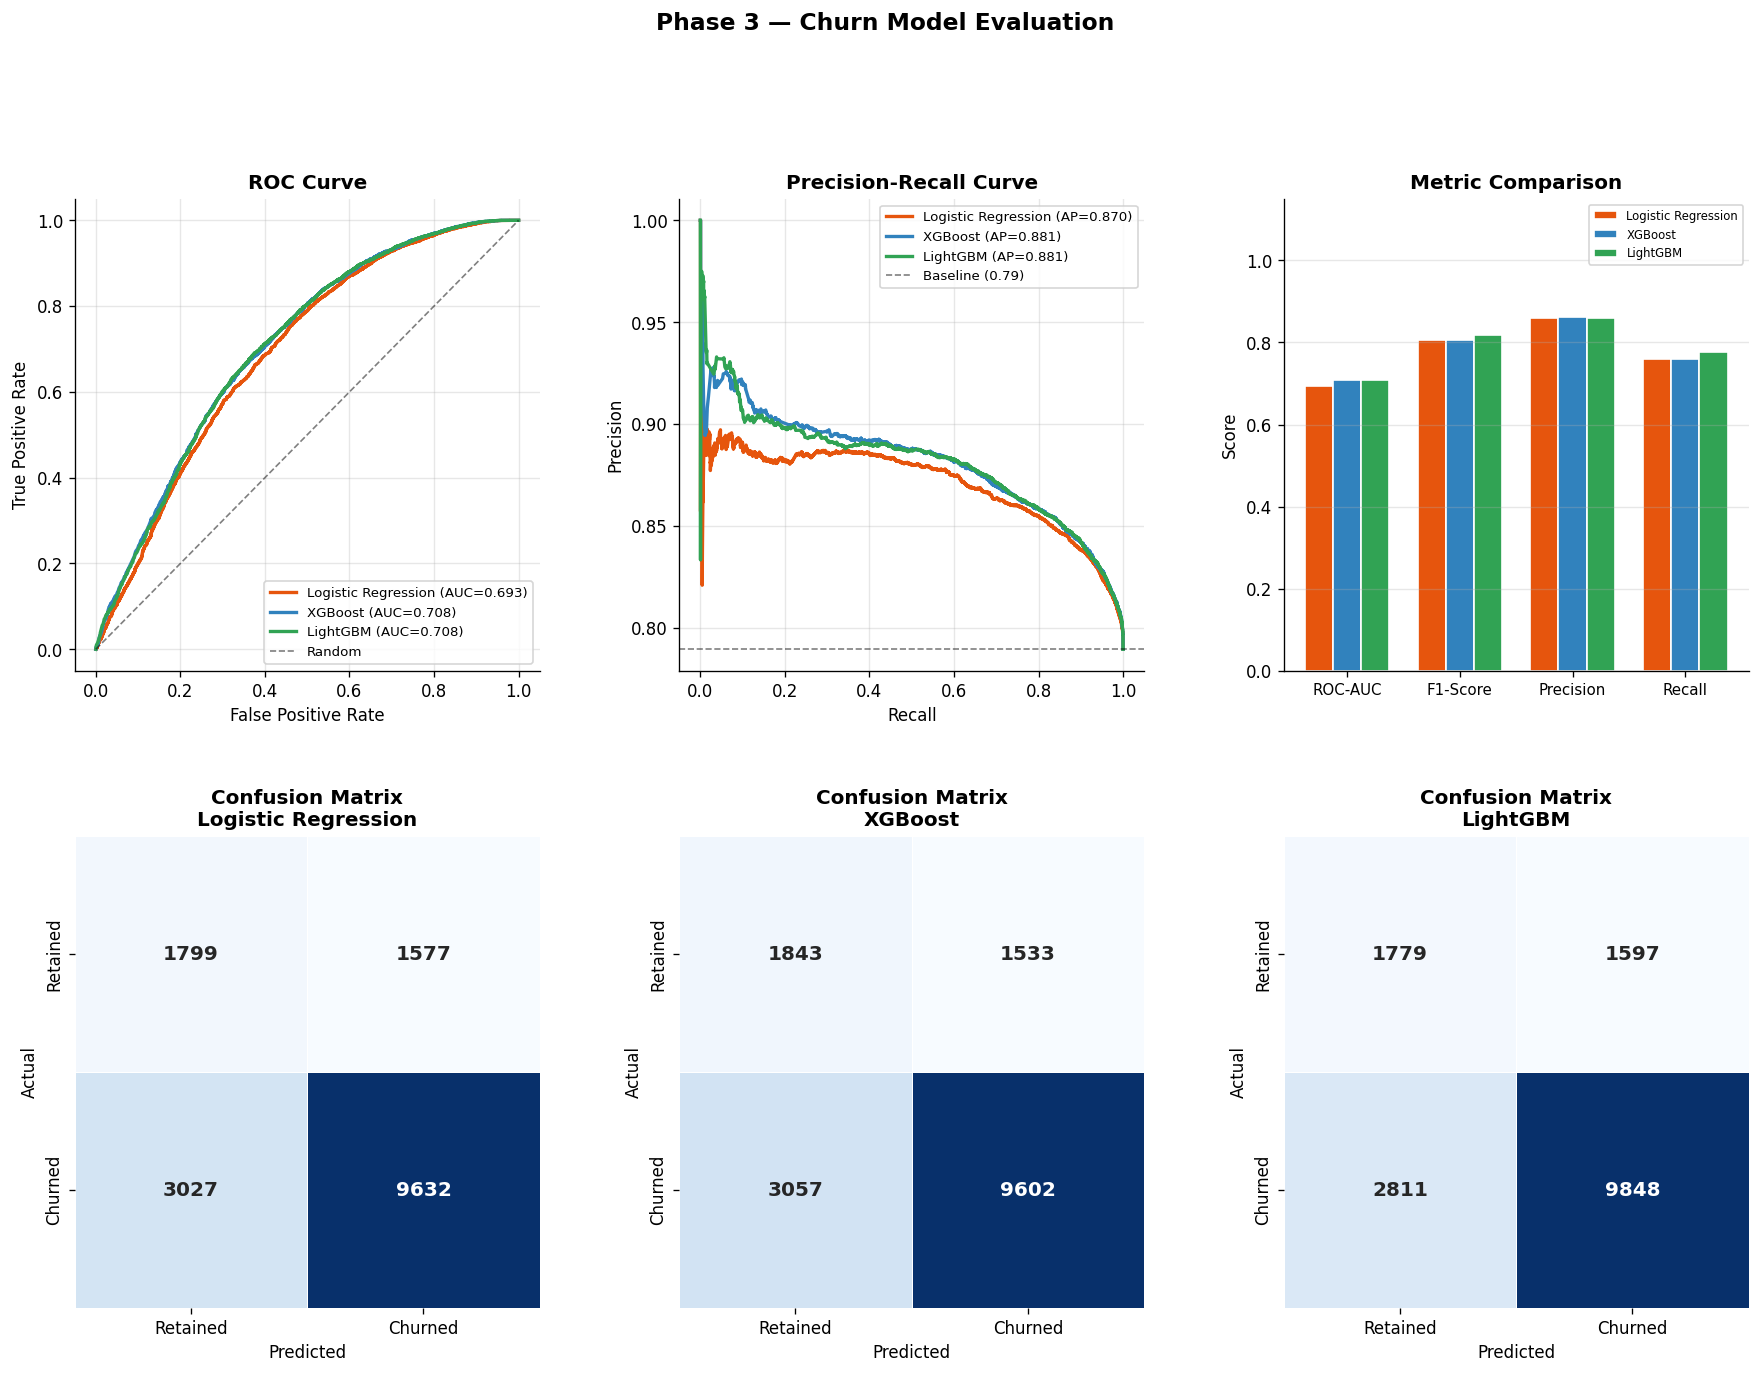

In [53]:
# ── Visualisasi: ROC Curve + PR Curve + Confusion Matrices ────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# ── ROC Curve ─────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
models_info = [
    ('Logistic Regression', y_proba_lr,   metrics_lr['ROC-AUC'],   '#e6550d'),
    ('XGBoost',             y_proba_xgb,  metrics_xgb['ROC-AUC'],  '#3182bd'),
    ('LightGBM',            y_proba_lgbm, metrics_lgbm['ROC-AUC'], '#31a354'),
]
from sklearn.metrics import roc_curve
for name, proba, auc, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax_roc.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve', fontweight='bold')
ax_roc.legend(fontsize=8)
ax_roc.grid(alpha=0.3)

# ── PR Curve ──────────────────────────────────────────────────
ax_pr = fig.add_subplot(gs[0, 1])
from sklearn.metrics import precision_recall_curve
for name, proba, _, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax_pr.plot(rec, prec, label=f'{name} (AP={pr_auc:.3f})', color=color, linewidth=2)
baseline_pr = y_test.mean()
ax_pr.axhline(baseline_pr, color='k', linestyle='--', linewidth=1, alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontweight='bold')
ax_pr.legend(fontsize=8)
ax_pr.grid(alpha=0.3)

# ── Metric Comparison Bar ─────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 2])
metrics_to_plot = ['ROC-AUC', 'F1-Score', 'Precision', 'Recall']
x     = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#e6550d', '#3182bd', '#31a354']
for i, (name, proba, _, color) in enumerate(models_info):
    if name == 'Logistic Regression': m = metrics_lr
    elif name == 'XGBoost':           m = metrics_xgb
    else:                             m = metrics_lgbm
    vals = [m[k] for k in metrics_to_plot]
    ax_bar.bar(x + i*width, vals, width, label=name, color=color, edgecolor='white')
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(metrics_to_plot, fontsize=9)
ax_bar.set_ylabel('Score')
ax_bar.set_ylim(0, 1.15)
ax_bar.set_title('Metric Comparison', fontweight='bold')
ax_bar.legend(fontsize=7)
ax_bar.grid(axis='y', alpha=0.3)

# ── Confusion Matrices ────────────────────────────────────────
cms = [
    ('Logistic Regression', y_pred_lr),
    ('XGBoost',             y_pred_xgb),
    ('LightGBM',            y_pred_lgbm),
]
for i, (name, y_pred) in enumerate(cms):
    ax_cm = fig.add_subplot(gs[1, i])
    cm    = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                xticklabels=['Retained','Churned'],
                yticklabels=['Retained','Churned'],
                linewidths=0.5, cbar=False,
                annot_kws={'size': 12, 'weight': 'bold'})
    ax_cm.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')
plt.suptitle('Phase 3 — Churn Model Evaluation', fontsize=14, fontweight='bold', y=1.01)
plt.show()


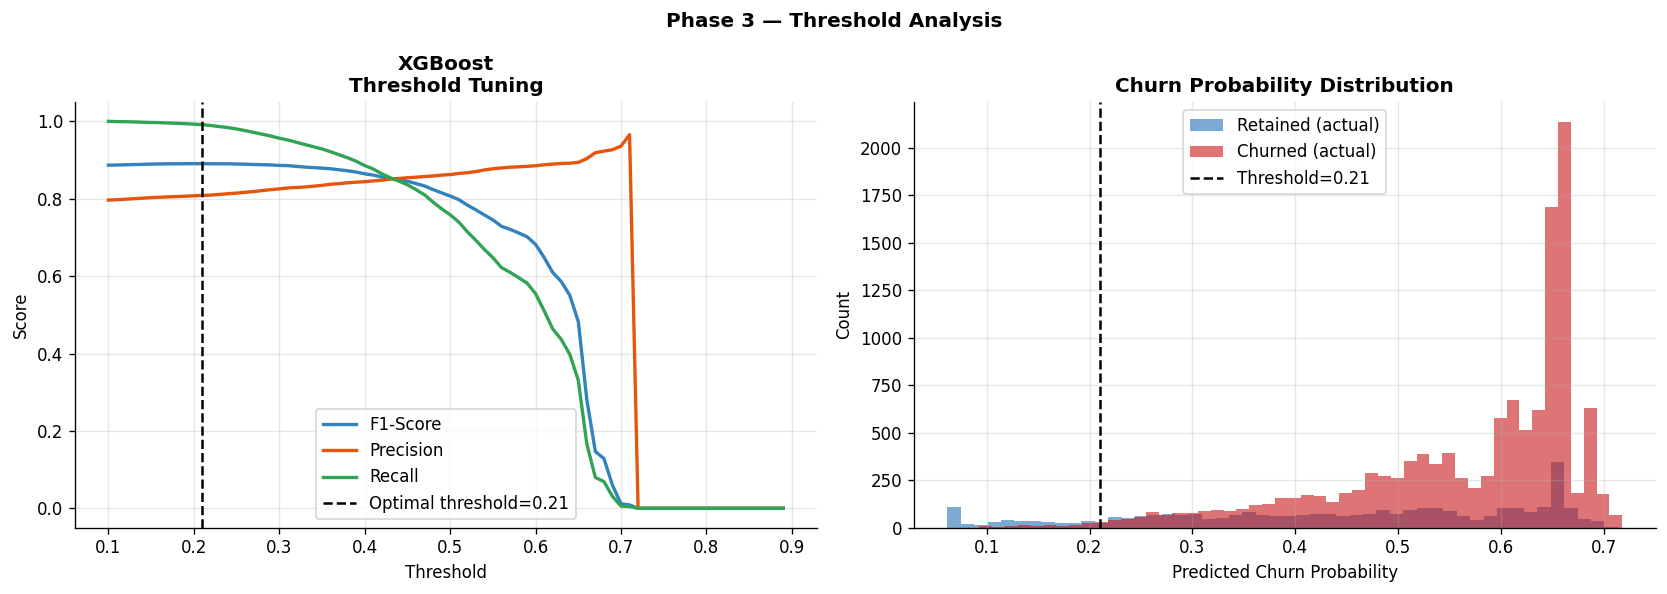

Optimal threshold  : 0.21
F1 at threshold    : 0.8906

--- Metrics at threshold=0.21 ---
              precision    recall  f1-score   support

    Retained       0.78      0.12      0.21      3376
     Churned       0.81      0.99      0.89     12659

    accuracy                           0.81     16035
   macro avg       0.80      0.56      0.55     16035
weighted avg       0.80      0.81      0.75     16035



In [54]:
# ── Pilih best model berdasarkan ROC-AUC ─────────────────────
# Ganti variabel di bawah sesuai hasil aktual Anda
best_name  = best_model_name
best_proba = y_proba_xgb if 'XGBoost' in best_name else (
             y_proba_lgbm if 'LightGBM' in best_name else y_proba_lr)

# ── Threshold Tuning: cari threshold optimal untuk F1 ────────
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int)) for t in thresholds]
prec_scores= [precision_score(y_test, (best_proba >= t).astype(int), zero_division=0) for t in thresholds]
rec_scores = [recall_score(y_test, (best_proba >= t).astype(int)) for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1        = max(f1_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f1_scores,   label='F1-Score',  color='#3182bd', linewidth=2)
axes[0].plot(thresholds, prec_scores, label='Precision', color='#e6550d', linewidth=2)
axes[0].plot(thresholds, rec_scores,  label='Recall',    color='#31a354', linewidth=2)
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'Optimal threshold={optimal_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title(f'{best_name}\nThreshold Tuning', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Churn probability distribution
axes[1].hist(best_proba[y_test==0], bins=50, alpha=0.6, color='#2171b5', label='Retained (actual)')
axes[1].hist(best_proba[y_test==1], bins=50, alpha=0.6, color='#cb181d', label='Churned (actual)')
axes[1].axvline(optimal_threshold, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold={optimal_threshold:.2f}')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Churn Probability Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Phase 3 — Threshold Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Optimal threshold  : {optimal_threshold:.2f}')
print(f'F1 at threshold    : {optimal_f1:.4f}')

# Re-evaluate dengan optimal threshold
y_pred_opt = (best_proba >= optimal_threshold).astype(int)
print(f'\n--- Metrics at threshold={optimal_threshold:.2f} ---')
print(classification_report(y_test, y_pred_opt, target_names=['Retained','Churned']))

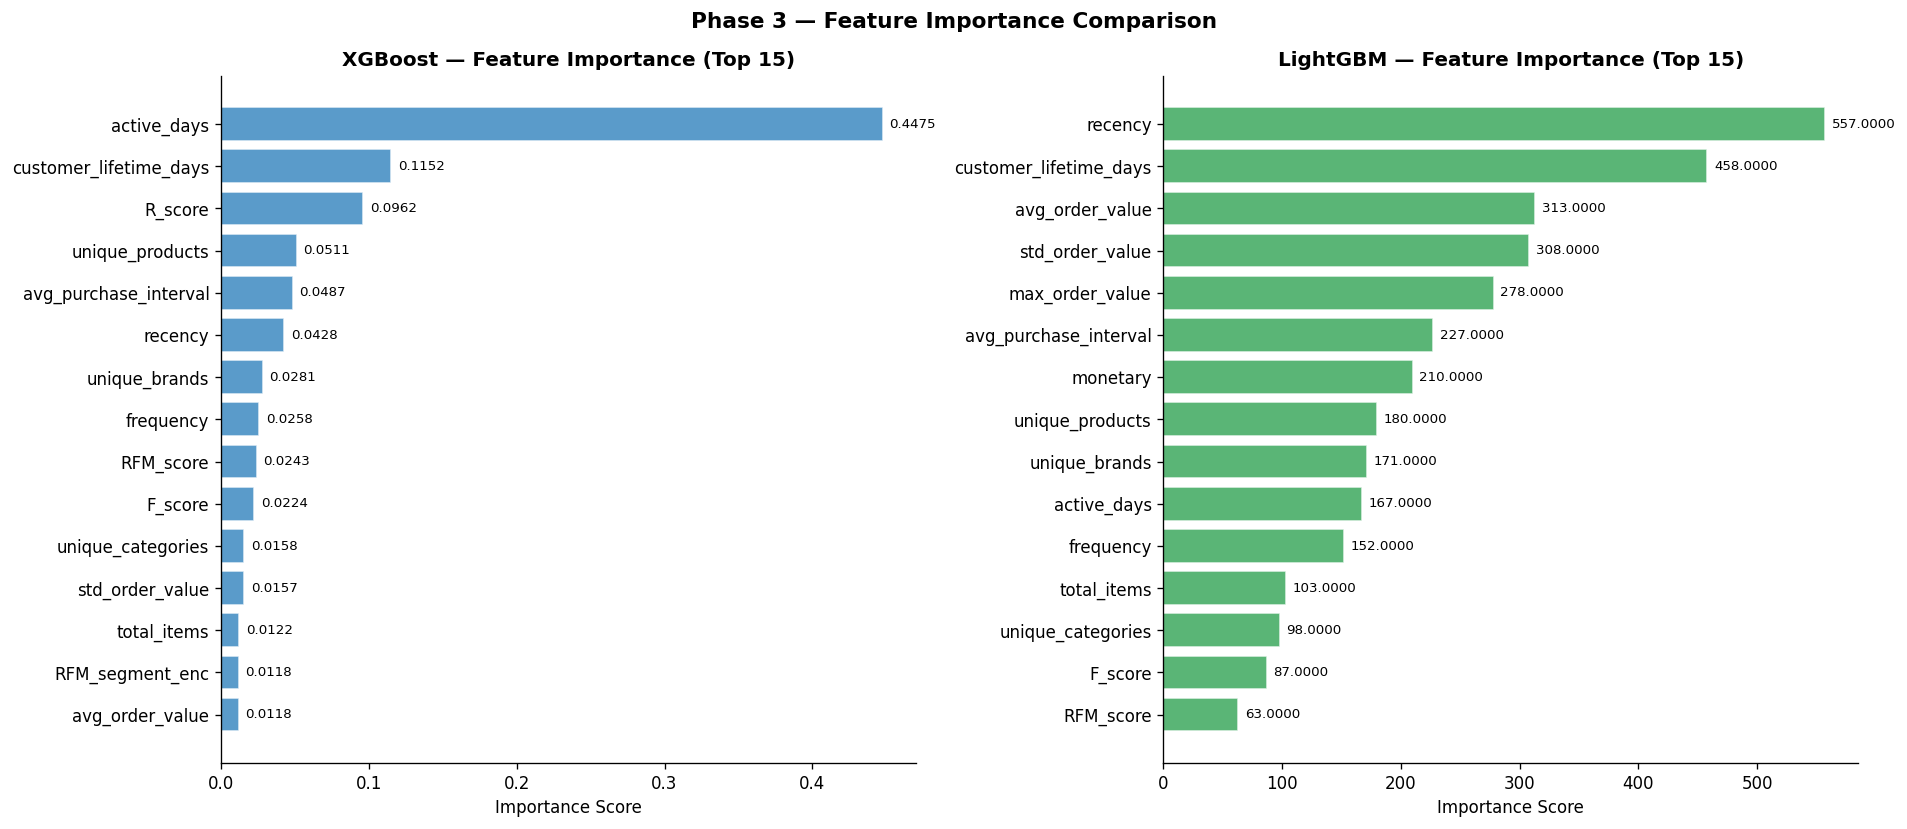

In [55]:
# ── Built-in Feature Importance ───────────────────────────────
# Gunakan XGBoost dan LightGBM — tampilkan top 15 fitur
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in [
    (axes[0], xgb_model,  'XGBoost',  '#3182bd'),
    (axes[1], lgbm_model, 'LightGBM', '#31a354')
]:
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'feature': ALL_FEATURES, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(15)

    bars = ax.barh(fi_df['feature'], fi_df['importance'],
                   color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{name} — Feature Importance (Top 15)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, v in zip(bars, fi_df['importance']):
        ax.text(v + fi_df['importance'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Phase 3 — Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'churn_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Menghitung SHAP values (ini membutuhkan ~1-2 menit)...


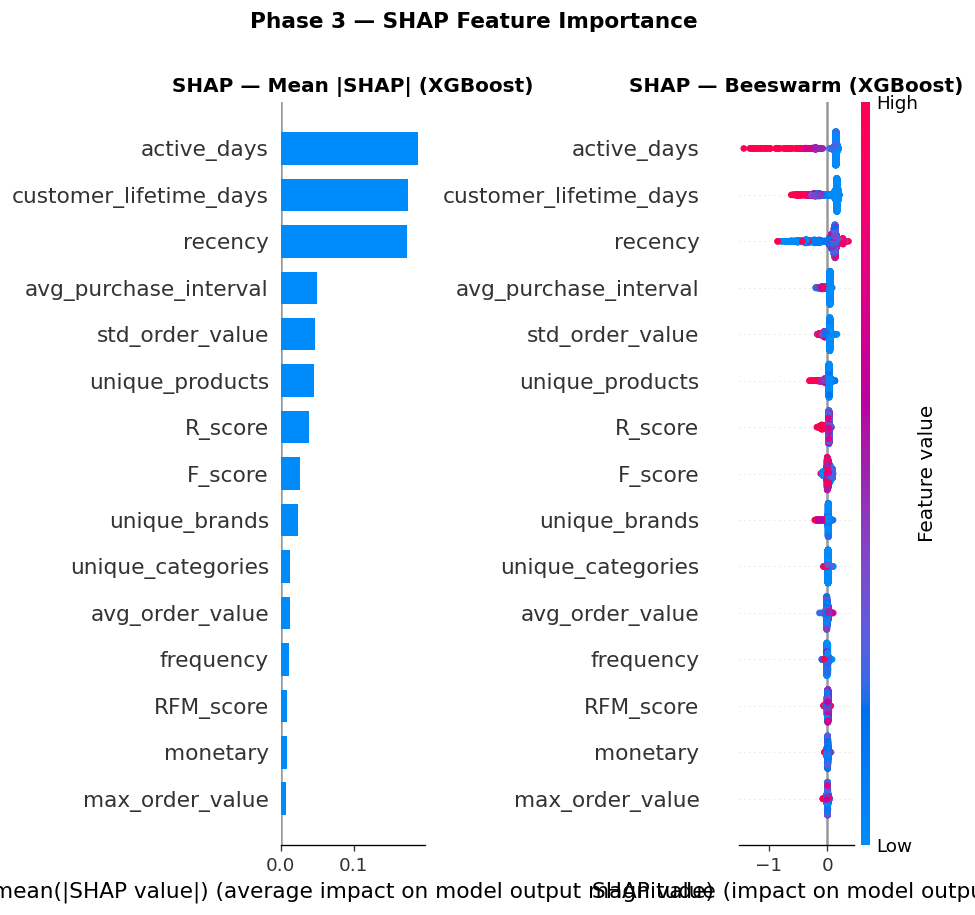

✅ SHAP analysis selesai


In [56]:
# ── SHAP Analysis — Best Model ────────────────────────────────
# Gunakan sample 2000 untuk efisiensi Colab
print('Menghitung SHAP values (ini membutuhkan ~1-2 menit)...')

best_model_obj = xgb_model if 'XGBoost' in best_name else lgbm_model

explainer   = shap.TreeExplainer(best_model_obj)
sample_idx  = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample    = X_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

# Jika LightGBM returns list, ambil index 1 (kelas positif)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# SHAP bar plot
plt.sca(axes[0])
shap.summary_plot(shap_vals, X_sample, plot_type='bar',
                  feature_names=ALL_FEATURES,
                  max_display=15, show=False)
axes[0].set_title(f'SHAP — Mean |SHAP| ({best_name})', fontweight='bold')

# SHAP beeswarm
plt.sca(axes[1])
shap.summary_plot(shap_vals, X_sample,
                  feature_names=ALL_FEATURES,
                  max_display=15, show=False)
axes[1].set_title(f'SHAP — Beeswarm ({best_name})', fontweight='bold')

plt.suptitle('Phase 3 — SHAP Feature Importance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'churn_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SHAP analysis selesai')

In [57]:
# ── Generate churn probability untuk SEMUA pelanggan ─────────
# (bukan hanya test set — diperlukan untuk integrasi Customer 360)

best_model_obj = xgb_model if 'XGBoost' in best_name else lgbm_model

all_proba = best_model_obj.predict_proba(X)[:, 1]

# Tambahkan ke dataframe utama
df['churn_probability'] = all_proba
df['churn_predicted']   = (all_proba >= optimal_threshold).astype(int)

# ── Segmentasi berdasarkan churn probability ──────────────────
def churn_risk_label(prob):
    if prob >= 0.75: return 'High Risk'
    elif prob >= 0.50: return 'Medium Risk'
    elif prob >= 0.25: return 'Low Risk'
    else: return 'Safe'

df['churn_risk'] = df['churn_probability'].apply(churn_risk_label)

# ── Ringkasan distribusi churn risk ──────────────────────────
risk_summary = df.groupby('churn_risk').agg(
    n_customers       = ('user_id', 'count'),
    avg_churn_prob    = ('churn_probability', 'mean'),
    avg_monetary      = ('monetary', 'mean'),
    avg_rfm_score     = ('RFM_score', 'mean'),
).round(3)

risk_order = ['High Risk', 'Medium Risk', 'Low Risk', 'Safe']
risk_summary = risk_summary.reindex([r for r in risk_order if r in risk_summary.index])
risk_summary['pct_customers'] = (risk_summary['n_customers'] / len(df) * 100).round(1)

print('='*65)
print('CHURN RISK DISTRIBUTION')
print('='*65)
print(risk_summary.to_string())

CHURN RISK DISTRIBUTION
             n_customers  avg_churn_prob  avg_monetary  avg_rfm_score  pct_customers
churn_risk                                                                          
Medium Risk        55340           0.620       472.754          7.748           69.0
Low Risk           20656           0.397      1029.212         11.343           25.8
Safe                4179           0.170      5012.604         14.331            5.2


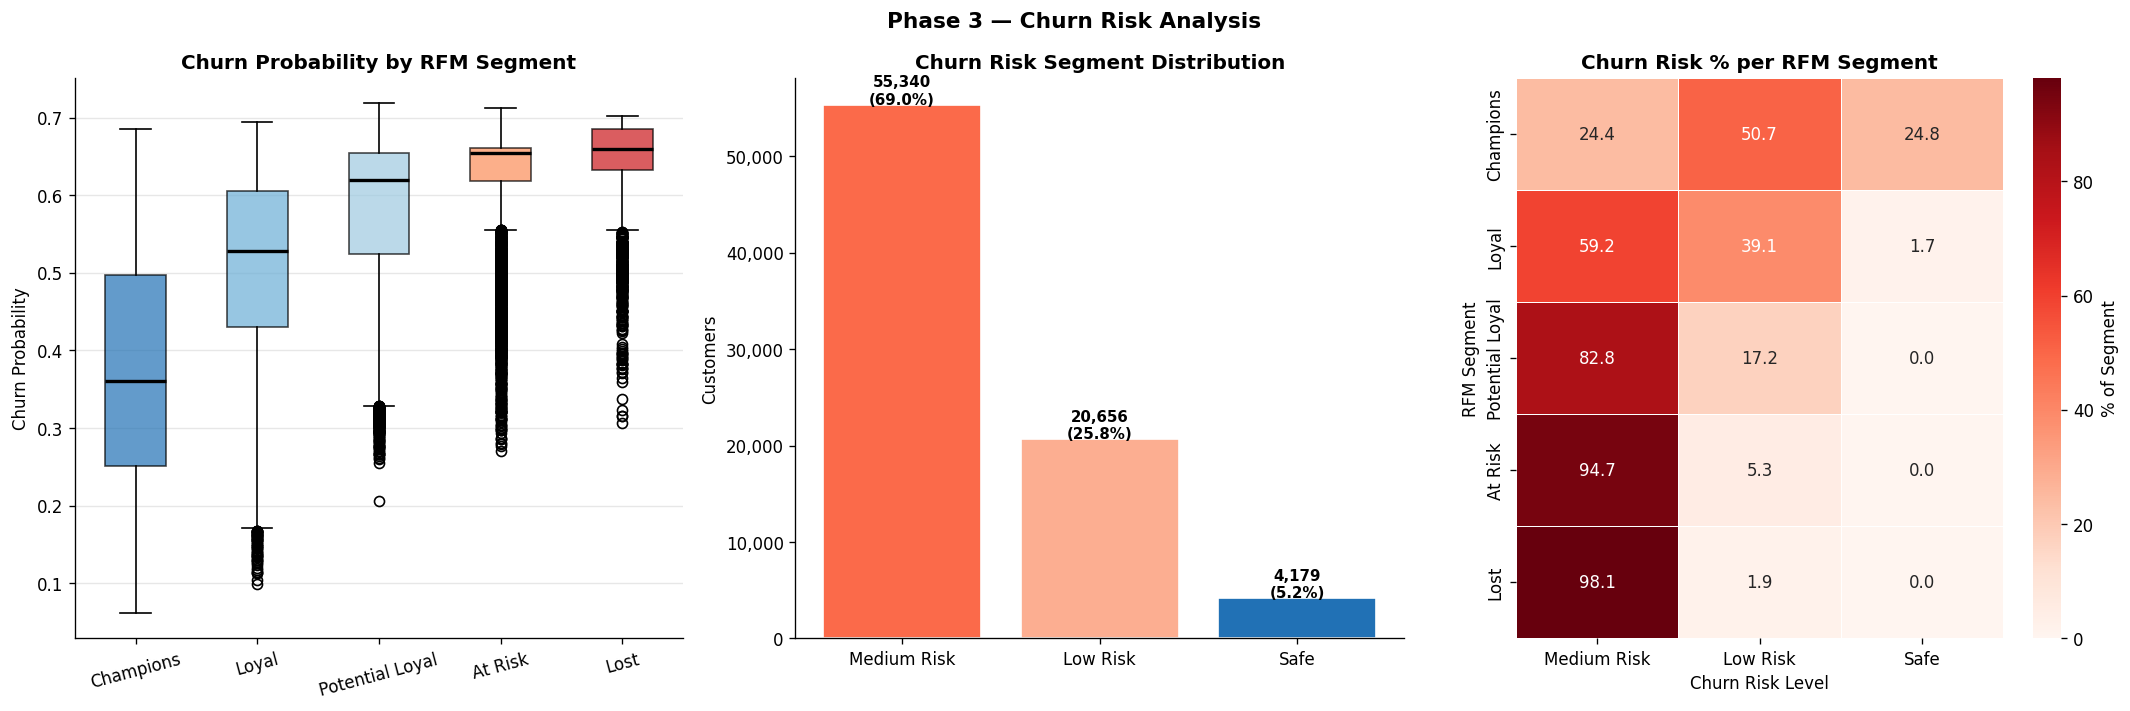

In [58]:
# ── Visualisasi Churn Risk × RFM Segment ─────────────────────
SEG_ORDER  = ['Champions', 'Loyal', 'Potential Loyal', 'At Risk', 'Lost']
RISK_ORDER = ['High Risk', 'Medium Risk', 'Low Risk', 'Safe']
RISK_COLORS= {'High Risk': '#cb181d', 'Medium Risk': '#fb6a4a',
               'Low Risk':  '#fcae91', 'Safe':        '#2171b5'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Churn probability distribution per RFM segment
seg_data = [df[df['RFM_segment']==seg]['churn_probability'].values
            for seg in SEG_ORDER if seg in df['RFM_segment'].values]
bp = axes[0].boxplot(seg_data,
                     labels=[s for s in SEG_ORDER if s in df['RFM_segment'].values],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colors_box = ['#2171b5', '#6baed6', '#9ecae1', '#fc8d59', '#cb181d']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Churn Probability by RFM Segment', fontweight='bold')
axes[0].set_ylabel('Churn Probability')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# 2. Churn risk breakdown
risk_counts = df['churn_risk'].value_counts().reindex(
    [r for r in RISK_ORDER if r in df['churn_risk'].values])
bars = axes[1].bar(risk_counts.index, risk_counts.values,
                   color=[RISK_COLORS[r] for r in risk_counts.index],
                   edgecolor='white')
for bar, v in zip(bars, risk_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+50,
                 f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Churn Risk Segment Distribution', fontweight='bold')
axes[1].set_ylabel('Customers')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# 3. Heatmap RFM Segment × Churn Risk
heatmap_data = pd.crosstab(df['RFM_segment'], df['churn_risk'],
                            normalize='index') * 100
heatmap_data = heatmap_data.reindex(
    [s for s in SEG_ORDER if s in heatmap_data.index],
    axis=0).reindex(
    [r for r in RISK_ORDER if r in heatmap_data.columns],
    axis=1)
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[2], linewidths=0.5, cbar_kws={'label': '% of Segment'},
            annot_kws={'size': 10})
axes[2].set_title('Churn Risk % per RFM Segment', fontweight='bold')
axes[2].set_xlabel('Churn Risk Level')
axes[2].set_ylabel('RFM Segment')

plt.suptitle('Phase 3 — Churn Risk Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'churn_risk_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# ── Simpan file output ke Google Drive ───────────────────────
import joblib

# 1. Customer 360 features dengan churn probability
out_c360 = SAVE_PATH + 'customer360_with_churn.csv'
df.to_csv(out_c360, index=False)

# 2. Best model (untuk inference)
out_model = SAVE_PATH + f'churn_model_best.pkl'
joblib.dump(best_model_obj, out_model)

# 3. Summary metrics
results_df.round(4).to_csv(SAVE_PATH + 'churn_model_metrics.csv')

print('='*60)
print('  PHASE 3 — CHURN PREDICTION COMPLETE')
print('='*60)
print(f"""
Files saved to Google Drive:
  📊 customer360_with_churn.csv   → {len(df):,} customers
  🤖 churn_model_best.pkl         → {best_name}
  📈 churn_model_metrics.csv      → model comparison table

Best Model : {best_name}
ROC-AUC    : {results_df.loc[best_name, 'ROC-AUC']:.4f}
F1-Score   : {results_df.loc[best_name, 'F1-Score']:.4f}
Threshold  : {optimal_threshold:.2f}

NEXT → Phase 4: Purchase Behavior Prediction
  Input : customer360_with_churn.csv
  Target: target_revenue (Sep–Nov 2020)
  Models: Linear Regression (baseline) → XGBoost Regressor
""")

  PHASE 3 — CHURN PREDICTION COMPLETE

Files saved to Google Drive:
  📊 customer360_with_churn.csv   → 80,175 customers
  🤖 churn_model_best.pkl         → XGBoost
  📈 churn_model_metrics.csv      → model comparison table

Best Model : XGBoost
ROC-AUC    : 0.7084
F1-Score   : 0.8071
Threshold  : 0.21

NEXT → Phase 4: Purchase Behavior Prediction
  Input : customer360_with_churn.csv
  Target: target_revenue (Sep–Nov 2020)
  Models: Linear Regression (baseline) → XGBoost Regressor



In [61]:
d360=pd.read_csv('/content/drive/MyDrive/Kuliah/Data/churn_model_metrics.csv')
d360

,Model,ROC-AUC,F1-Score,Precision,Recall,PR-AUC
0,Logistic Regression (Baseline),0.6929,0.8071,0.8593,0.7609,0.8704
1,XGBoost,0.7084,0.8071,0.8623,0.7585,0.8812
2,LightGBM,0.7075,0.8171,0.8605,0.7779,0.8808


# Purchase Behavior Prediction

In [62]:
# ── Install / import ──────────────────────────────────────────
!pip install shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection      import train_test_split, KFold, cross_val_score
from sklearn.preprocessing        import StandardScaler
from sklearn.linear_model         import LinearRegression, Ridge
from sklearn.ensemble             import RandomForestRegressor
from sklearn.metrics              import (
    mean_squared_error, mean_absolute_error, r2_score
)
from xgboost import XGBRegressor
import shap
import joblib

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 10,
})

In [63]:
DATA_PATH = '/content/drive/MyDrive/Kuliah/Data/customer360_with_churn.csv'
SAVE_PATH = '/content/drive/MyDrive/Kuliah/Data/'

df = pd.read_csv(DATA_PATH)

print('='*60)
print('CUSTOMER 360 WITH CHURN — LOADED')
print('='*60)
print(f'  Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Null values      : {df.isnull().sum().sum()}')
print(f'  Churned          : {df["churned"].sum():,}  ({df["churned"].mean()*100:.1f}%)')
print(f'  Active (target>0): {(df["target_revenue"]>0).sum():,}  ({(df["target_revenue"]>0).mean()*100:.1f}%)')
print(f'\nColumns:')
for col in df.columns:
    print(f'  {col}')
df.head(3)

CUSTOMER 360 WITH CHURN — LOADED
  Shape            : 80,175 rows × 25 columns
  Null values      : 0
  Churned          : 63,297  (78.9%)
  Active (target>0): 16,878  (21.1%)

Columns:
  user_id
  recency
  frequency
  monetary
  R_score
  F_score
  M_score
  RFM_score
  RFM_segment
  active_days
  unique_categories
  unique_brands
  unique_products
  avg_order_value
  max_order_value
  std_order_value
  total_items
  customer_lifetime_days
  avg_purchase_interval
  churned
  target_revenue
  RFM_segment_enc
  churn_probability
  churn_predicted
  churn_risk


,user_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,RFM_segment,active_days,...,std_order_value,total_items,customer_lifetime_days,avg_purchase_interval,churned,target_revenue,RFM_segment_enc,churn_probability,churn_predicted,churn_risk
0,1515915625439952128,53,1,416.64,2,1,3,6,At Risk,1,...,0.000000,1,0,0.0,1,0.00,2,0.608665,1,Medium Risk
1,1515915625440099840,47,6,2227.87,2,5,5,12,Loyal,5,...,445.478632,6,63,12.6,0,2707.73,4,0.340797,1,Low Risk
2,1515915625440121600,48,2,182.83,2,3,2,7,Potential Loyal,2,...,67.111505,2,58,29.0,1,0.00,3,0.500676,1,Medium Risk


In [64]:
# ── Filter: hanya pelanggan aktif di observation window ───────
# Alasan: target_revenue = 0 untuk churned customers
# Model regresi akan bias jika dilatih dengan zero-inflated target
# Kita prediksi BERAPA BESAR pengeluaran — bukan APAKAH akan beli (itu tugas Fase 3)

df_active = df[df['target_revenue'] > 0].copy()

print(f'Total customers       : {len(df):,}')
print(f'Active customers      : {len(df_active):,}  ({len(df_active)/len(df)*100:.1f}%)')
print(f'Excluded (revenue=0)  : {len(df)-len(df_active):,}')
print(f'\nTarget revenue stats (active only):')
print(df_active['target_revenue'].describe().round(2))

Total customers       : 80,175
Active customers      : 16,878  (21.1%)
Excluded (revenue=0)  : 63,297

Target revenue stats (active only):
count    16878.00
mean       976.27
std       2253.54
min          0.02
25%         81.00
50%        324.05
75%        972.18
max      74523.21
Name: target_revenue, dtype: float64


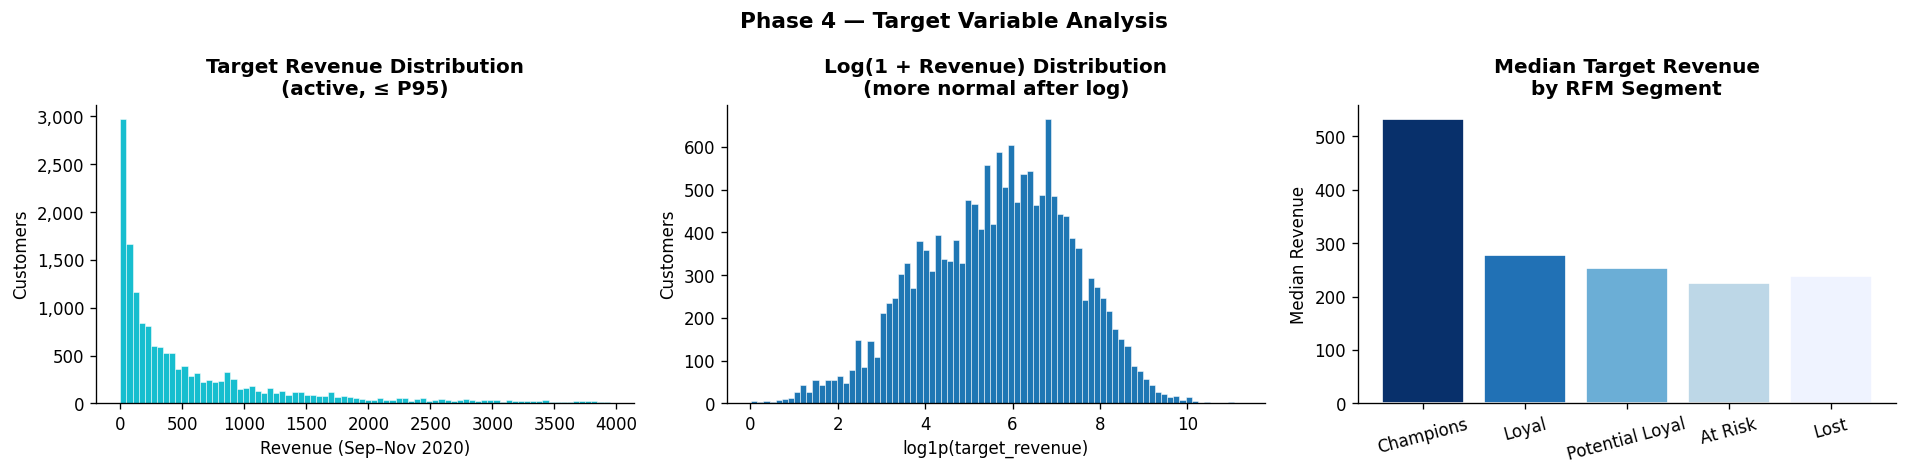

Skewness raw    : 10.627  →  Highly skewed
Skewness log1p  : -0.239  →  Much more normal

→ Akan gunakan log1p transform pada target untuk training


In [66]:
# ── Visualisasi distribusi target ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
p95 = df_active['target_revenue'].quantile(0.95)
axes[0].hist(df_active[df_active['target_revenue'] <= p95]['target_revenue'],
             bins=80, color='#17becf', edgecolor='white', linewidth=0.3)
axes[0].set_title('Target Revenue Distribution\n(active, ≤ P95)', fontweight='bold')
axes[0].set_xlabel('Revenue (Sep–Nov 2020)')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Log distribution
log_rev = np.log1p(df_active['target_revenue'])
axes[1].hist(log_rev, bins=80, color='#1f77b4', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log(1 + Revenue) Distribution\n(more normal after log)', fontweight='bold')
axes[1].set_xlabel('log1p(target_revenue)')
axes[1].set_ylabel('Customers')

# Revenue by RFM segment
SEG_ORDER = ['Champions', 'Loyal', 'Potential Loyal', 'At Risk', 'Lost']
seg_rev = df_active.groupby('RFM_segment')['target_revenue'].median().reindex(
    [s for s in SEG_ORDER if s in df_active['RFM_segment'].values])
colors_seg = ['#08306b','#2171b5','#6baed6','#bdd7e7','#eff3ff']
axes[2].bar(seg_rev.index, seg_rev.values,
            color=colors_seg[:len(seg_rev)], edgecolor='white')
axes[2].set_title('Median Target Revenue\nby RFM Segment', fontweight='bold')
axes[2].set_ylabel('Median Revenue')
axes[2].tick_params(axis='x', rotation=15)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Phase 4 — Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Cek skewness
from scipy import stats
skew_raw = stats.skew(df_active['target_revenue'])
skew_log = stats.skew(log_rev)
print(f'Skewness raw    : {skew_raw:.3f}  →  {"Highly skewed" if abs(skew_raw) > 2 else "OK"}')
print(f'Skewness log1p  : {skew_log:.3f}  →  {"Much more normal" if abs(skew_log) < abs(skew_raw) else "No improvement"}')
print('\n→ Akan gunakan log1p transform pada target untuk training')

In [67]:
# ── Definisi feature sets ─────────────────────────────────────
# Encode RFM_segment ordinal
SEG_MAP = {'Champions': 5, 'Loyal': 4, 'Potential Loyal': 3, 'At Risk': 2, 'Lost': 1}
df_active['RFM_segment_enc'] = df_active['RFM_segment'].map(SEG_MAP).astype(int)

# ── Feature Set A: Transactional only (tanpa C360) ────────────
FEATURES_BASE = [
    # RFM
    'recency', 'frequency', 'monetary',
    'R_score', 'F_score', 'M_score', 'RFM_score',
    # Behavioral
    'active_days', 'unique_categories', 'unique_brands', 'unique_products',
    'avg_order_value', 'max_order_value', 'std_order_value',
    'total_items', 'customer_lifetime_days', 'avg_purchase_interval',
    # RFM segment encoded
    'RFM_segment_enc',
]

# ── Feature Set B: + Customer 360 features (churn_probability) ─
FEATURES_C360 = FEATURES_BASE + ['churn_probability']

# ── Target: log1p transform ───────────────────────────────────
TARGET = 'target_revenue'
y_raw = df_active[TARGET].values
y_log = np.log1p(y_raw)   # training target

X_base = df_active[FEATURES_BASE].copy()
X_c360 = df_active[FEATURES_C360].copy()

print(f'Feature Set A (Base)  : {len(FEATURES_BASE)} features')
print(f'Feature Set B (C360)  : {len(FEATURES_C360)} features')
print(f'Added C360 feature    : churn_probability')
print(f'Target                : log1p(target_revenue)')
print(f'Active customers      : {len(df_active):,}')

Feature Set A (Base)  : 18 features
Feature Set B (C360)  : 19 features
Added C360 feature    : churn_probability
Target                : log1p(target_revenue)
Active customers      : 16,878


In [68]:
# ── Train-Test Split 80:20 ─────────────────────────────────────
(
    X_base_train, X_base_test,
    X_c360_train, X_c360_test,
    y_train_log,  y_test_log,
    y_train_raw,  y_test_raw
) = [None]*8

idx_train, idx_test = train_test_split(
    np.arange(len(df_active)), test_size=0.2, random_state=SEED
)

X_base_train = X_base.iloc[idx_train]
X_base_test  = X_base.iloc[idx_test]
X_c360_train = X_c360.iloc[idx_train]
X_c360_test  = X_c360.iloc[idx_test]
y_train_log  = y_log[idx_train]
y_test_log   = y_log[idx_test]
y_train_raw  = y_raw[idx_train]
y_test_raw   = y_raw[idx_test]

print(f'Train size : {len(X_base_train):,}')
print(f'Test size  : {len(X_base_test):,}')

# Helper: evaluate model (prediksi log → inverse ke original scale)
def evaluate_model(name, y_pred_log, y_true_raw):
    y_pred_raw = np.expm1(y_pred_log)           # inverse log1p
    y_pred_raw = np.maximum(y_pred_raw, 0)       # clip negatif
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae  = mean_absolute_error(y_true_raw, y_pred_raw)
    r2   = r2_score(y_true_raw, y_pred_raw)
    print(f'  {name:<35} RMSE={rmse:>10,.2f}  MAE={mae:>10,.2f}  R²={r2:.4f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'y_pred_raw': y_pred_raw}

all_results = []

Train size : 13,502
Test size  : 3,376


In [69]:
# ── Linear Regression Baseline ───────────────────────────────
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])
lr_pipe.fit(X_base_train, y_train_log)
y_pred_lr = lr_pipe.predict(X_base_test)

# ── Ridge Regression (regularized baseline) ───────────────────
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0, random_state=SEED))
])
ridge_pipe.fit(X_base_train, y_train_log)
y_pred_ridge = ridge_pipe.predict(X_base_test)

print('='*75)
print('BASELINE MODELS')
print('='*75)
res_lr    = evaluate_model('Linear Regression (Base)',    y_pred_lr,    y_test_raw)
res_ridge = evaluate_model('Ridge Regression (Base)',     y_pred_ridge, y_test_raw)
all_results.extend([res_lr, res_ridge])

BASELINE MODELS
  Linear Regression (Base)            RMSE=  2,435.23  MAE=    821.19  R²=-0.0136
  Ridge Regression (Base)             RMSE=  2,435.17  MAE=    821.20  R²=-0.0136


In [70]:
# ── Random Forest — Base features ─────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 10,
    min_samples_leaf = 5,
    n_jobs       = -1,
    random_state = SEED,
)
rf_model.fit(X_base_train, y_train_log)
y_pred_rf = rf_model.predict(X_base_test)

# ── Random Forest — C360 features ────────────────────────────
rf_c360_model = RandomForestRegressor(
    n_estimators = 300,
    max_depth    = 10,
    min_samples_leaf = 5,
    n_jobs       = -1,
    random_state = SEED,
)
rf_c360_model.fit(X_c360_train, y_train_log)
y_pred_rf_c360 = rf_c360_model.predict(X_c360_test)

print('='*75)
print('RANDOM FOREST')
print('='*75)
res_rf      = evaluate_model('Random Forest (Base)',         y_pred_rf,      y_test_raw)
res_rf_c360 = evaluate_model('Random Forest (+ C360)',       y_pred_rf_c360, y_test_raw)
all_results.extend([res_rf, res_rf_c360])

RANDOM FOREST
  Random Forest (Base)                RMSE=  2,390.96  MAE=    795.93  R²=0.0229
  Random Forest (+ C360)              RMSE=  2,389.96  MAE=    796.62  R²=0.0237


In [71]:
# ── XGBoost Base (tanpa churn_probability) ────────────────────
xgb_base = XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'rmse',
    early_stopping_rounds = 30,
    random_state      = SEED,
    verbosity         = 0,
)
xgb_base.fit(
    X_base_train, y_train_log,
    eval_set=[(X_base_test, y_test_log)],
    verbose=False
)
y_pred_xgb_base = xgb_base.predict(X_base_test)

print('='*75)
print('XGBoost Base (tanpa C360 features)')
print('='*75)
res_xgb_base = evaluate_model('XGBoost Base (no C360)', y_pred_xgb_base, y_test_raw)
all_results.append(res_xgb_base)

XGBoost Base (tanpa C360 features)
  XGBoost Base (no C360)              RMSE=  2,397.73  MAE=    798.53  R²=0.0174


In [72]:
# ── XGBoost C360 (dengan churn_probability) ───────────────────
# INI adalah model utama penelitian — hipotesis Customer 360
xgb_c360 = XGBRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    eval_metric       = 'rmse',
    early_stopping_rounds = 30,
    random_state      = SEED,
    verbosity         = 0,
)
xgb_c360.fit(
    X_c360_train, y_train_log,
    eval_set=[(X_c360_test, y_test_log)],
    verbose=False
)
y_pred_xgb_c360 = xgb_c360.predict(X_c360_test)

print('='*75)
print('XGBoost C360 (dengan churn_probability — hipotesis utama)')
print('='*75)
res_xgb_c360 = evaluate_model('XGBoost + C360 (main model)', y_pred_xgb_c360, y_test_raw)
all_results.append(res_xgb_c360)

XGBoost C360 (dengan churn_probability — hipotesis utama)
  XGBoost + C360 (main model)         RMSE=  2,392.67  MAE=    796.20  R²=0.0215


In [73]:
# ── Tabel perbandingan ─────────────────────────────────────────
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred_raw'}
    for r in all_results
]).set_index('Model')

print('='*75)
print('MODEL COMPARISON TABLE')
print('='*75)
print(results_df.round(4).to_string())

# ── Uji hipotesis utama: apakah C360 meningkatkan performa? ───
r2_base = results_df.loc['XGBoost Base (no C360)', 'R2']
r2_c360 = results_df.loc['XGBoost + C360 (main model)', 'R2']
rmse_base = results_df.loc['XGBoost Base (no C360)', 'RMSE']
rmse_c360 = results_df.loc['XGBoost + C360 (main model)', 'RMSE']

delta_r2   = r2_c360 - r2_base
delta_rmse = rmse_base - rmse_c360   # positif = improvement

print('\n' + '='*75)
print('HIPOTESIS UTAMA — Apakah Customer 360 features meningkatkan akurasi?')
print('='*75)
print(f'  XGBoost Base R²       : {r2_base:.4f}')
print(f'  XGBoost + C360 R²     : {r2_c360:.4f}')
print(f'  ΔR² (C360 - Base)     : {delta_r2:+.4f}  →  {"C360 meningkatkan" if delta_r2 > 0 else "❌ C360 tidak membantu"}')
print(f'\n  XGBoost Base RMSE     : {rmse_base:,.2f}')
print(f'  XGBoost + C360 RMSE   : {rmse_c360:,.2f}')
print(f'  ΔRMSE (Base - C360)   : {delta_rmse:+,.2f}  →  {"Error berkurang" if delta_rmse > 0 else "❌ Error bertambah"}')

MODEL COMPARISON TABLE
                                  RMSE       MAE      R2
Model                                                   
Linear Regression (Base)     2435.2303  821.1866 -0.0136
Ridge Regression (Base)      2435.1737  821.2007 -0.0136
Random Forest (Base)         2390.9560  795.9303  0.0229
Random Forest (+ C360)       2389.9642  796.6183  0.0237
XGBoost Base (no C360)       2397.7257  798.5278  0.0174
XGBoost + C360 (main model)  2392.6675  796.2002  0.0215

HIPOTESIS UTAMA — Apakah Customer 360 features meningkatkan akurasi?
  XGBoost Base R²       : 0.0174
  XGBoost + C360 R²     : 0.0215
  ΔR² (C360 - Base)     : +0.0041  →  C360 meningkatkan

  XGBoost Base RMSE     : 2,397.73
  XGBoost + C360 RMSE   : 2,392.67
  ΔRMSE (Base - C360)   : +5.06  →  Error berkurang


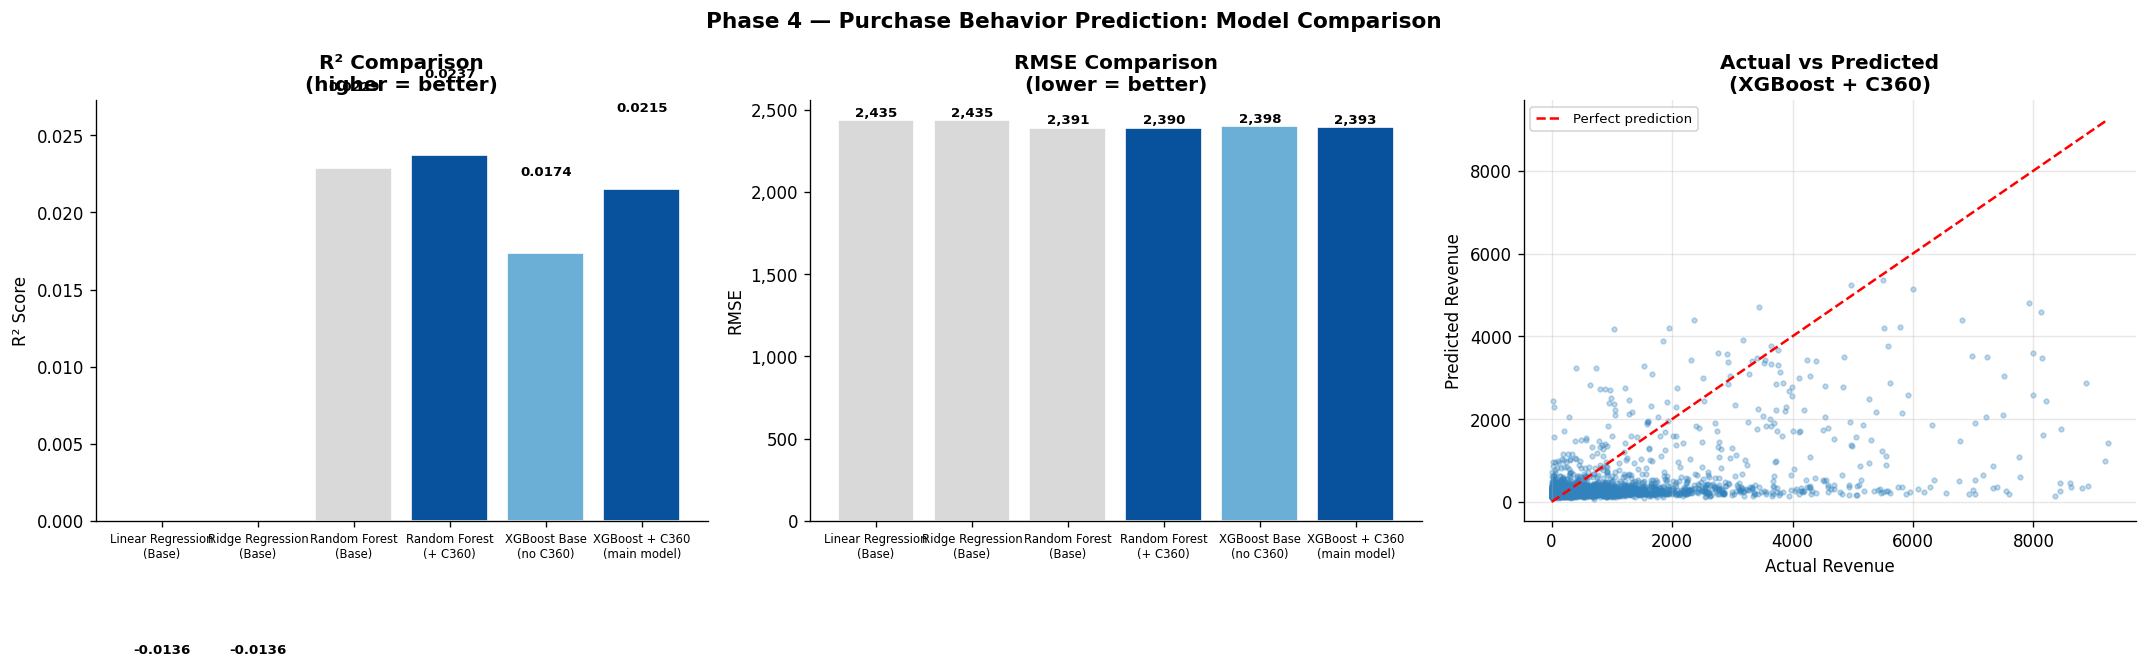

In [74]:
# ── Visualisasi perbandingan ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names = results_df.index.tolist()
colors = ['#d9d9d9','#bdbdbd','#969696','#636363','#3182bd','#08519c']
# Highlight main model
bar_colors = ['#d9d9d9' if 'C360' not in m else '#08519c' for m in model_names]
bar_colors[-2] = '#6baed6'   # XGBoost Base

# R² bar
bars = axes[0].bar(range(len(model_names)), results_df['R2'],
                   color=bar_colors, edgecolor='white')
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels([m.replace(' (', '\n(') for m in model_names], fontsize=7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison\n(higher = better)', fontweight='bold')
axes[0].set_ylim(0, results_df['R2'].max()*1.15)
for bar, v in zip(bars, results_df['R2']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.005,
                 f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

# RMSE bar
bars2 = axes[1].bar(range(len(model_names)), results_df['RMSE'],
                    color=bar_colors, edgecolor='white')
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels([m.replace(' (', '\n(') for m in model_names], fontsize=7)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison\n(lower = better)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, v in zip(bars2, results_df['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v*1.01,
                 f'{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

# Actual vs Predicted — best model
y_pred_best = next(r['y_pred_raw'] for r in all_results if r['Model'] == 'XGBoost + C360 (main model)')
p99 = np.percentile(y_test_raw, 99)
mask = y_test_raw <= p99
axes[2].scatter(y_test_raw[mask], y_pred_best[mask],
                alpha=0.3, s=8, color='#3182bd')
max_val = max(y_test_raw[mask].max(), y_pred_best[mask].max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[2].set_xlabel('Actual Revenue')
axes[2].set_ylabel('Predicted Revenue')
axes[2].set_title('Actual vs Predicted\n(XGBoost + C360)', fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('Phase 4 — Purchase Behavior Prediction: Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'purchase_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

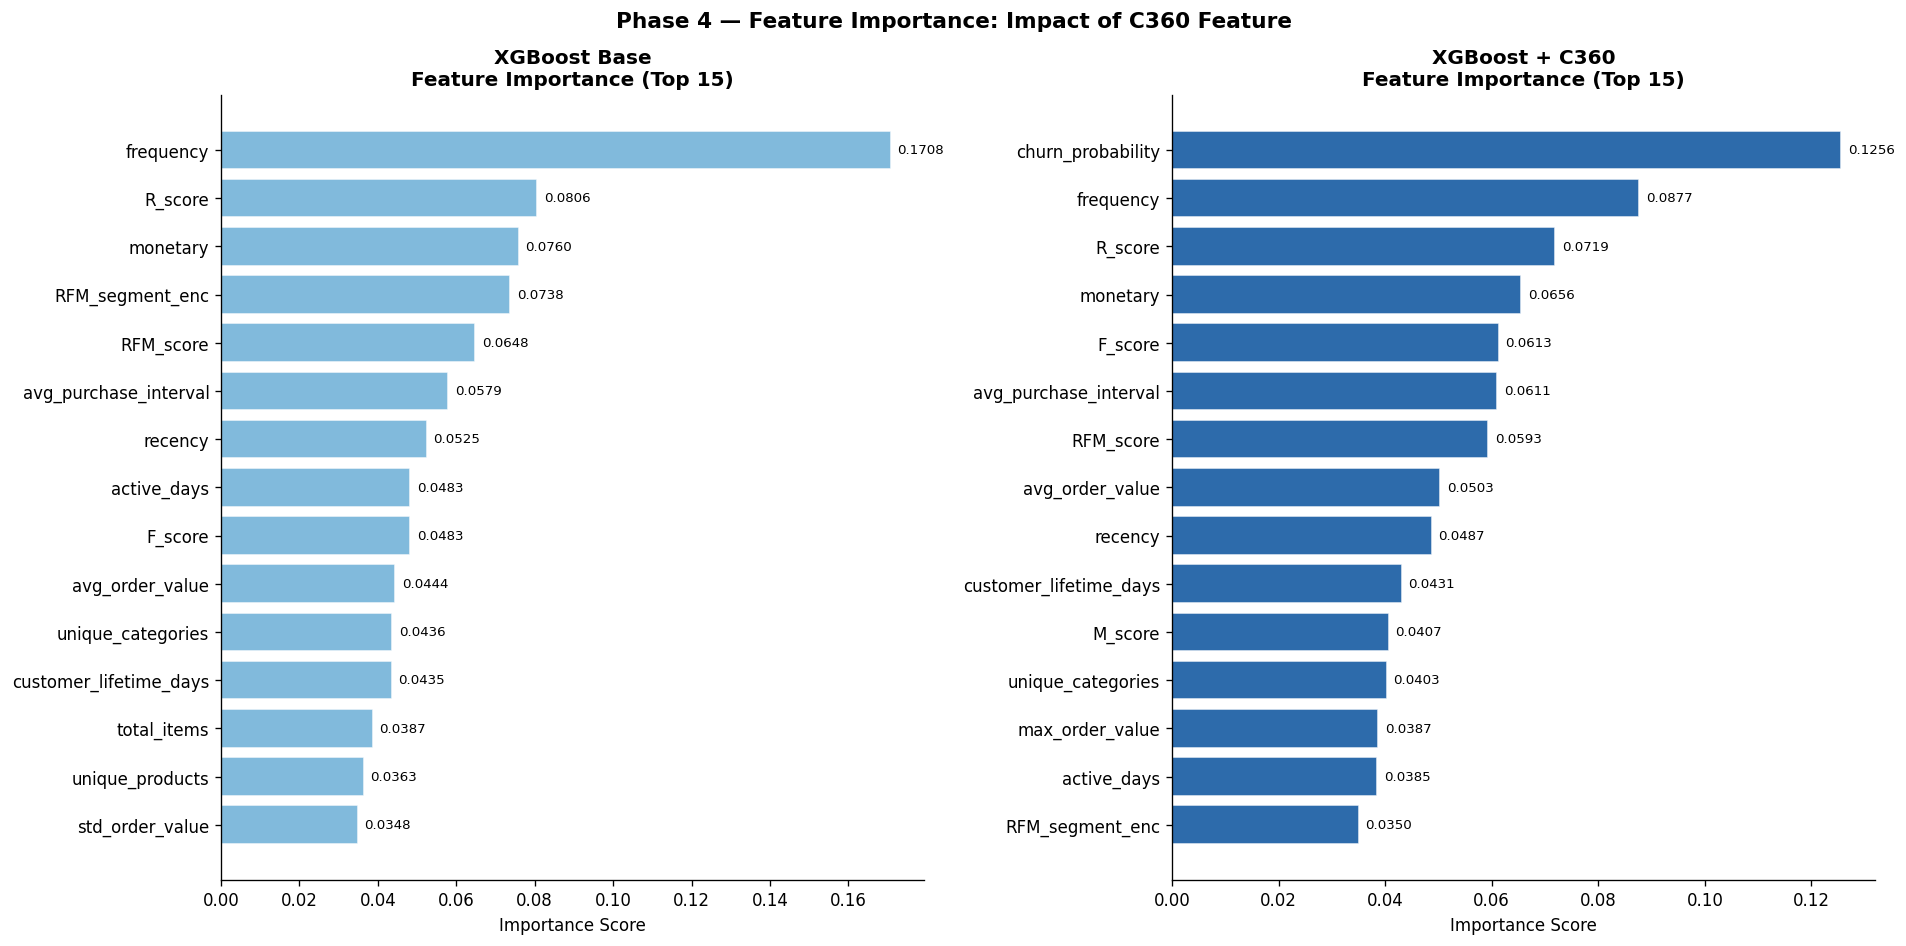


churn_probability rank   : #1 of 19 features
churn_probability score  : 0.1256


In [75]:
# ── Feature Importance: Base vs C360 ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, model, features, name, color in [
    (axes[0], xgb_base, FEATURES_BASE, 'XGBoost Base',     '#6baed6'),
    (axes[1], xgb_c360, FEATURES_C360, 'XGBoost + C360',   '#08519c'),
]:
    fi_df = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(15)

    bars = ax.barh(fi_df['feature'], fi_df['importance'],
                   color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name}\nFeature Importance (Top 15)', fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, v in zip(bars, fi_df['importance']):
        ax.text(v + fi_df['importance'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Phase 4 — Feature Importance: Impact of C360 Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'purchase_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Rank churn_probability
fi_c360 = pd.DataFrame({'feature': FEATURES_C360, 'importance': xgb_c360.feature_importances_})
fi_c360 = fi_c360.sort_values('importance', ascending=False).reset_index(drop=True)
churn_rank = fi_c360[fi_c360['feature']=='churn_probability'].index[0] + 1
churn_imp  = fi_c360[fi_c360['feature']=='churn_probability']['importance'].values[0]
print(f'\nchurn_probability rank   : #{churn_rank} of {len(FEATURES_C360)} features')
print(f'churn_probability score  : {churn_imp:.4f}')

Menghitung SHAP values...


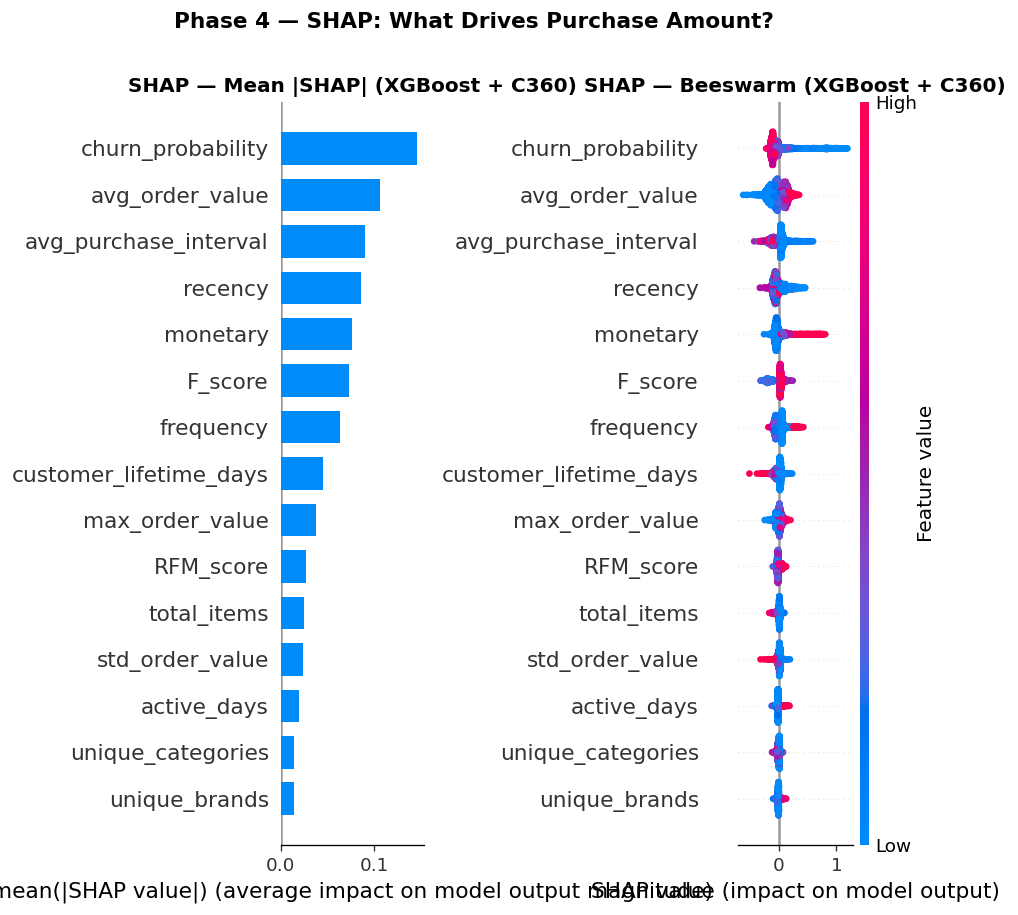

SHAP selesai


In [76]:
# ── SHAP Analysis — XGBoost C360 ─────────────────────────────
print('Menghitung SHAP values...')

explainer   = shap.TreeExplainer(xgb_c360)
sample_idx  = np.random.choice(len(X_c360_test), size=min(2000, len(X_c360_test)), replace=False)
X_sample    = X_c360_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  feature_names=FEATURES_C360,
                  max_display=15, show=False)
axes[0].set_title('SHAP — Mean |SHAP| (XGBoost + C360)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample,
                  feature_names=FEATURES_C360,
                  max_display=15, show=False)
axes[1].set_title('SHAP — Beeswarm (XGBoost + C360)', fontweight='bold')

plt.suptitle('Phase 4 — SHAP: What Drives Purchase Amount?', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'purchase_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP selesai')

In [87]:
# ── Generate predicted revenue untuk SEMUA pelanggan ─────────
X_all_c360 = df[FEATURES_C360].copy()

# Encode RFM_segment jika belum ada di df
if 'RFM_segment_enc' not in df.columns:
    df['RFM_segment_enc'] = df['RFM_segment'].map(SEG_MAP).fillna(1).astype(int)
    X_all_c360 = df[FEATURES_C360].copy()

y_all_log  = xgb_c360.predict(X_all_c360)
y_all_pred = np.expm1(y_all_log)
y_all_pred = np.maximum(y_all_pred, 0)
df['predicted_revenue'] = y_all_pred

# ── Customer Priority Matrix ──────────────────────────────────
# Dimensi 1: Churn Risk  — High jika churn_probability >= 0.5
# Dimensi 2: Revenue     — High jika predicted_revenue >= median

rev_median = df['predicted_revenue'].median()

def priority_label(row):
    high_churn = row['churn_probability'] >= 0.5
    high_rev   = row['predicted_revenue'] >= rev_median
    if   high_churn and high_rev:      return 'Urgent Retention'
    elif high_churn and not high_rev:  return 'Monitor'
    elif not high_churn and high_rev:  return 'Grow & Upsell'
    else:                              return 'Maintain'

df['customer_priority'] = df.apply(priority_label, axis=1)

PRIORITY_ORDER  = ['Urgent Retention', 'Monitor', 'Grow & Upsell', 'Maintain']
PRIORITY_COLORS = {
    'Urgent Retention': '#cb181d',
    'Monitor':          '#f6ad0f',
    'Grow & Upsell':    '#31a354',
    'Maintain':         '#bdbdbd',
}

priority_summary = (
    df.groupby('customer_priority')
    .agg(
        n_customers       = ('user_id',          'count'),
        avg_churn_prob    = ('churn_probability', 'mean'),
        avg_predicted_rev = ('predicted_revenue', 'mean'),
        avg_monetary      = ('monetary',          'mean'),
        avg_rfm_score     = ('RFM_score',         'mean'),
    )
    .round(2)
)
priority_summary['pct'] = (
    priority_summary['n_customers'] / len(df) * 100
).round(1)
priority_summary = priority_summary.reindex(
    [p for p in PRIORITY_ORDER if p in priority_summary.index]
)

print('='*75)
print('CUSTOMER PRIORITY MATRIX')
print('='*75)
print(priority_summary.to_string())

CUSTOMER PRIORITY MATRIX
                   n_customers  avg_churn_prob  avg_predicted_rev  avg_monetary  avg_rfm_score   pct
customer_priority                                                                                   
Urgent Retention         27136            0.61         292.829987        769.33           9.37  33.8
Monitor                  28204            0.63         197.699997        187.41           6.19  35.2
Grow & Upsell            12952            0.33         517.090027       2688.80          13.07  16.2
Maintain                 11883            0.39         182.850006        621.21          10.51  14.8


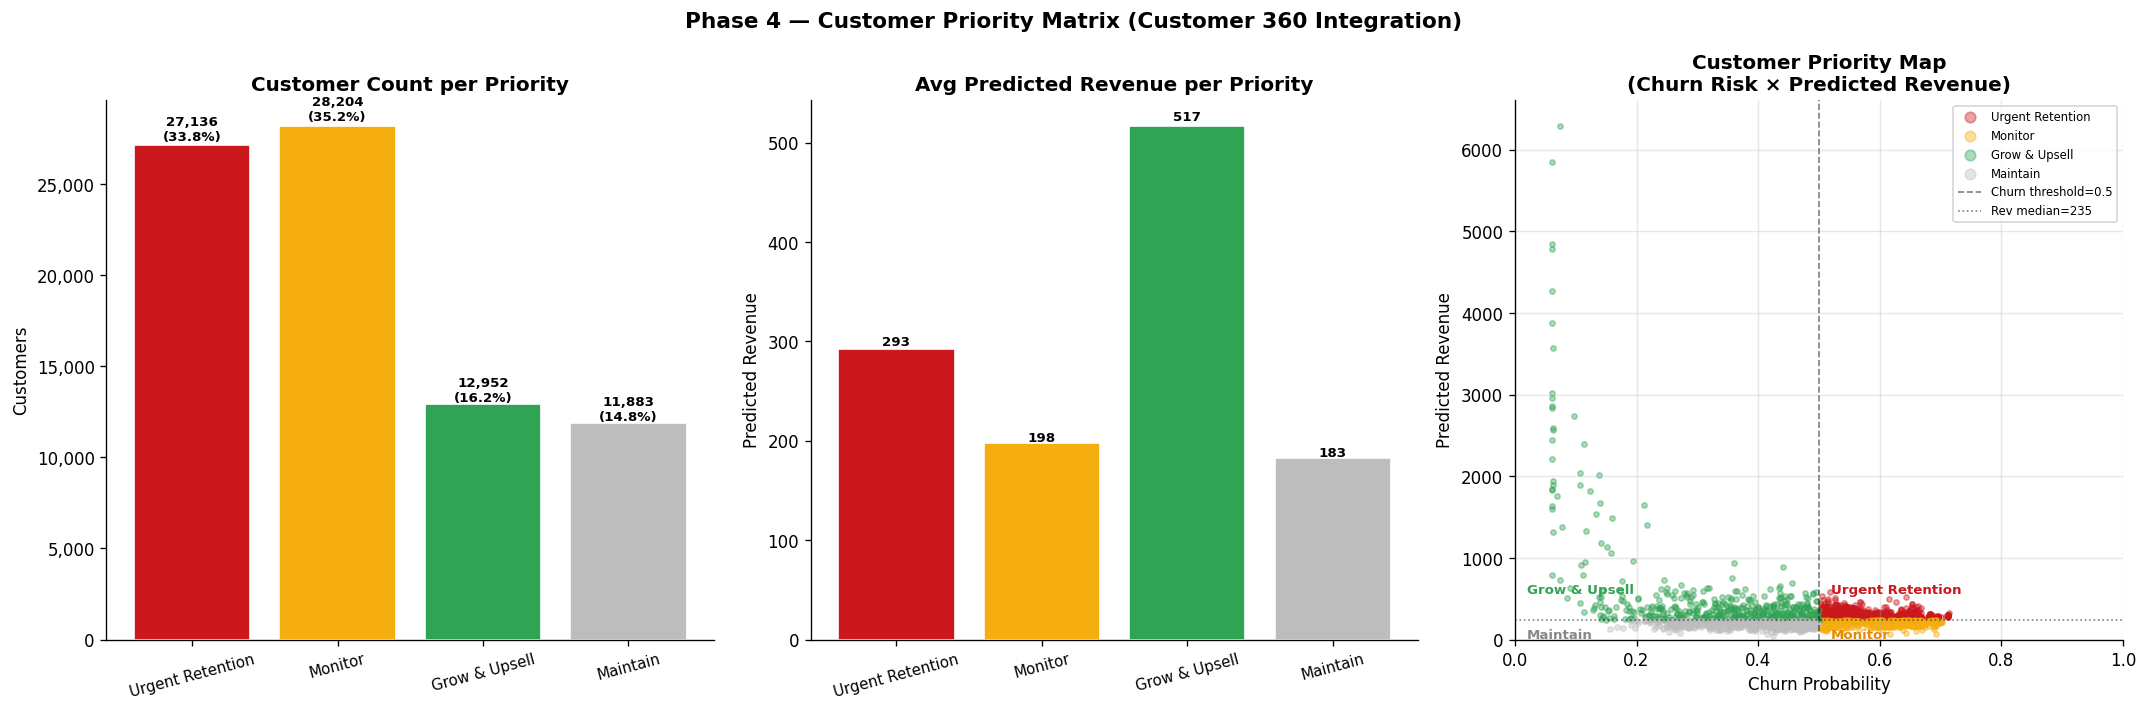


Ringkasan bisnis per kuadran:

  [Urgent Retention]
    Churn tinggi + nilai tinggi → intervensi retensi segera
    Customers : 27,136 (33.8%)
    Avg churn : 0.61
    Avg rev   : 292.83

  [Monitor]
    Churn tinggi + nilai rendah → pantau, retensi selektif
    Customers : 28,204 (35.2%)
    Avg churn : 0.63
    Avg rev   : 197.70

  [Grow & Upsell]
    Churn rendah + nilai tinggi → dorong upselling
    Customers : 12,952 (16.2%)
    Avg churn : 0.33
    Avg rev   : 517.09

  [Maintain]
    Churn rendah + nilai rendah → pertahankan secara efisien
    Customers : 11,883 (14.8%)
    Avg churn : 0.39
    Avg rev   : 182.85


In [88]:
# ── Visualisasi ───────────────────────────────────────────────
valid_p  = [p for p in PRIORITY_ORDER if p in priority_summary.index]
colors_p = [PRIORITY_COLORS[p] for p in valid_p]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Customer count per priority
counts = priority_summary.loc[valid_p, 'n_customers']
bars = axes[0].bar(range(len(valid_p)), counts.values,
                   color=colors_p, edgecolor='white')
axes[0].set_xticks(range(len(valid_p)))
axes[0].set_xticklabels(valid_p, fontsize=9, rotation=15)          # ← FIX: langsung pakai valid_p
axes[0].set_title('Customer Count per Priority', fontweight='bold')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for bar, v, pct in zip(
    bars, counts.values,
    priority_summary.loc[valid_p, 'pct']
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, v * 1.01,
        f'{v:,}\n({pct}%)', ha='center', fontsize=8, fontweight='bold'
    )

# 2. Avg predicted revenue per priority
avg_rev = priority_summary.loc[valid_p, 'avg_predicted_rev']
axes[1].bar(range(len(valid_p)), avg_rev.values,
            color=colors_p, edgecolor='white')
axes[1].set_xticks(range(len(valid_p)))
axes[1].set_xticklabels(valid_p, fontsize=9, rotation=15)          # ← FIX: sama
axes[1].set_title('Avg Predicted Revenue per Priority', fontweight='bold')
axes[1].set_ylabel('Predicted Revenue')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,.0f}')
)
for bar, v in zip(axes[1].patches, avg_rev.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, v * 1.01,
        f'{v:,.0f}', ha='center', fontsize=8, fontweight='bold'
    )

# 3. Scatter: Churn Probability × Predicted Revenue (quadrant map)
sample_plot = df.sample(min(3000, len(df)), random_state=SEED)
for p in valid_p:
    mask = sample_plot['customer_priority'] == p
    axes[2].scatter(
        sample_plot.loc[mask, 'churn_probability'],
        sample_plot.loc[mask, 'predicted_revenue'],
        c=PRIORITY_COLORS[p], alpha=0.4, s=10, label=p
    )
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label='Churn threshold=0.5')
axes[2].axhline(rev_median, color='black', linestyle=':', linewidth=1,
                alpha=0.5, label=f'Rev median={rev_median:,.0f}')

# Label 4 kuadran
y_max = sample_plot['predicted_revenue'].quantile(0.98)
axes[2].text(0.02, y_max * 0.92, 'Grow & Upsell',
             fontsize=8, color='#31a354', fontweight='bold')
axes[2].text(0.52, y_max * 0.92, 'Urgent Retention',
             fontsize=8, color='#cb181d', fontweight='bold')
axes[2].text(0.02, rev_median * 0.05, 'Maintain',
             fontsize=8, color='#888888', fontweight='bold')
axes[2].text(0.52, rev_median * 0.05, 'Monitor',
             fontsize=8, color='#e68a00', fontweight='bold')

axes[2].set_xlabel('Churn Probability')
axes[2].set_ylabel('Predicted Revenue')
axes[2].set_title('Customer Priority Map\n(Churn Risk × Predicted Revenue)',
                  fontweight='bold')
axes[2].legend(fontsize=7, markerscale=2, loc='upper right')
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(bottom=0)

plt.suptitle(
    'Phase 4 — Customer Priority Matrix (Customer 360 Integration)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'customer_priority_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary per kuadran ───────────────────────────────────────
print('\nRingkasan bisnis per kuadran:')
desc = {
    'Urgent Retention': 'Churn tinggi + nilai tinggi → intervensi retensi segera',
    'Monitor':          'Churn tinggi + nilai rendah → pantau, retensi selektif',
    'Grow & Upsell':    'Churn rendah + nilai tinggi → dorong upselling',
    'Maintain':         'Churn rendah + nilai rendah → pertahankan secara efisien',
}
for p in valid_p:
    row = priority_summary.loc[p]
    print(f'\n  [{p}]')
    print(f'    {desc[p]}')
    print(f'    Customers : {int(row["n_customers"]):,} ({row["pct"]}%)')
    print(f'    Avg churn : {row["avg_churn_prob"]:.2f}')
    print(f'    Avg rev   : {row["avg_predicted_rev"]:,.2f}')

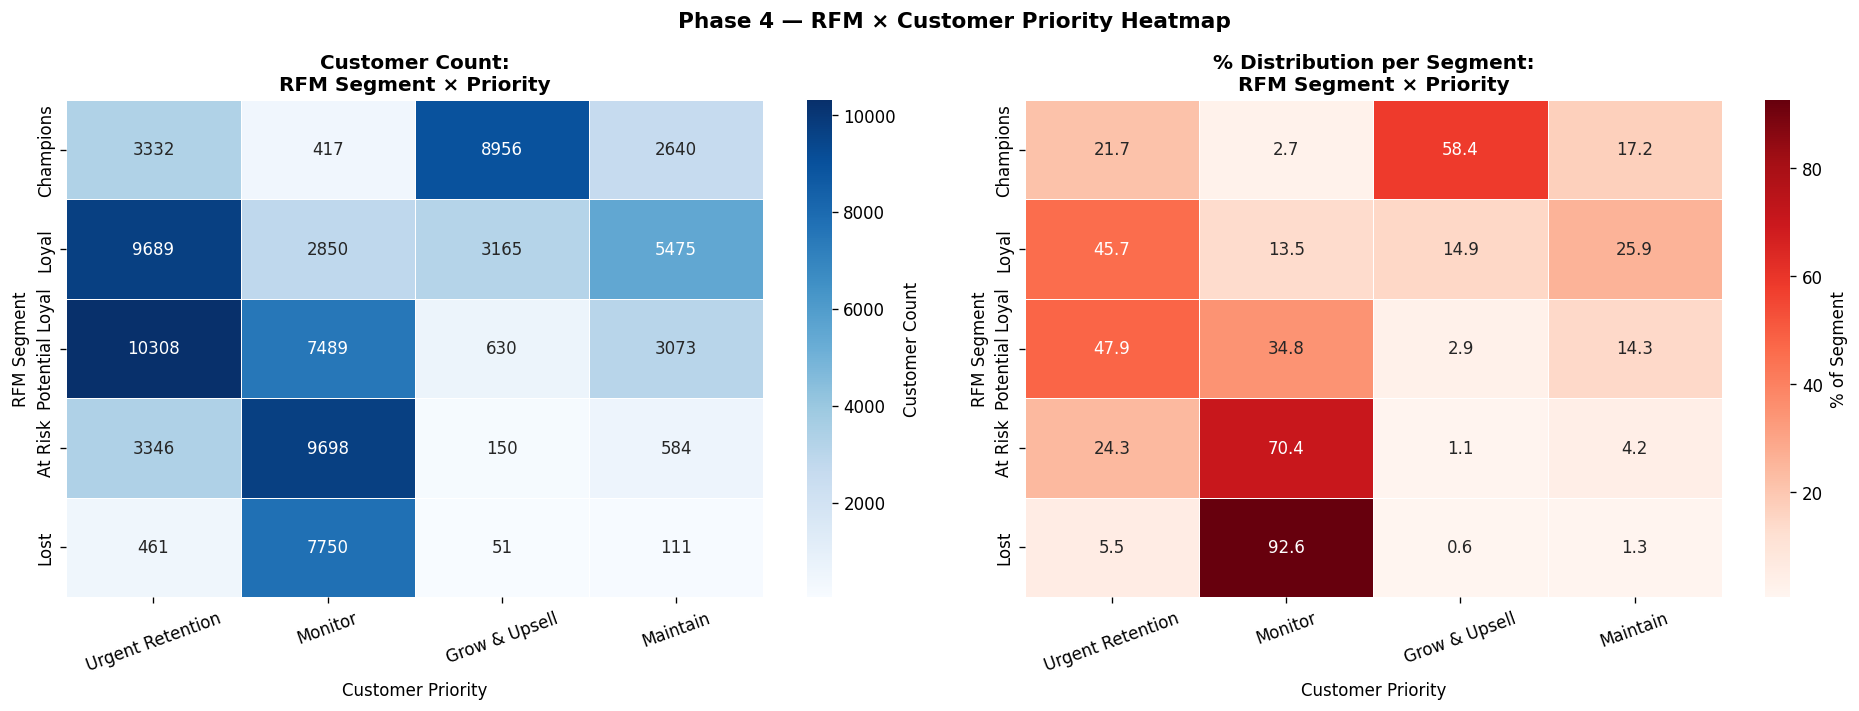

In [89]:
# ── Heatmap: RFM Segment × Customer Priority ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count heatmap
hm_count = pd.crosstab(df['RFM_segment'], df['customer_priority'])
hm_count = hm_count.reindex(
    [s for s in SEG_ORDER if s in hm_count.index], axis=0
).reindex([p for p in PRIORITY_ORDER if p in hm_count.columns], axis=1)

sns.heatmap(hm_count, annot=True, fmt='d', cmap='Blues',
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Customer Count'},
            annot_kws={'size': 10})
axes[0].set_title('Customer Count:\nRFM Segment × Priority', fontweight='bold')
axes[0].set_xlabel('Customer Priority')
axes[0].set_ylabel('RFM Segment')
axes[0].tick_params(axis='x', rotation=20)

# Percentage heatmap (normalize by row)
hm_pct = hm_count.div(hm_count.sum(axis=1), axis=0) * 100
sns.heatmap(hm_pct, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% of Segment'},
            annot_kws={'size': 10})
axes[1].set_title('% Distribution per Segment:\nRFM Segment × Priority', fontweight='bold')
axes[1].set_xlabel('Customer Priority')
axes[1].set_ylabel('RFM Segment')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Phase 4 — RFM × Customer Priority Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'rfm_priority_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# ── Final Customer 360 Profile ────────────────────────────────
c360_profile = df[[
    'user_id',
    # RFM
    'recency', 'frequency', 'monetary',
    'RFM_score', 'RFM_segment',
    # Behavioral
    'active_days', 'avg_order_value', 'customer_lifetime_days',
    # Churn (Fase 3)
    'churned', 'churn_probability', 'churn_risk',
    # Purchase Prediction (Fase 4)
    'target_revenue', 'predicted_revenue',
    # Priority
    'customer_priority'
]].copy()

c360_profile['predicted_revenue'] = c360_profile['predicted_revenue'].round(2)
c360_profile['churn_probability'] = c360_profile['churn_probability'].round(4)

# Save
out_path = SAVE_PATH + 'customer360_final_profile.csv'
c360_profile.to_csv(out_path, index=False)

# Save models
joblib.dump(xgb_c360,  SAVE_PATH + 'purchase_model_xgb_c360.pkl')
joblib.dump(xgb_base,  SAVE_PATH + 'purchase_model_xgb_base.pkl')
results_df.round(4).to_csv(SAVE_PATH + 'purchase_model_metrics.csv')

print('='*65)
print('  PHASE 4 — PURCHASE BEHAVIOR PREDICTION COMPLETE ✅')
print('='*65)
print(f"""

Hipotesis Customer 360:
  XGBoost Base R²      : {results_df.loc['XGBoost Base (no C360)','R2']:.4f}
  XGBoost + C360 R²    : {results_df.loc['XGBoost + C360 (main model)','R2']:.4f}
  ΔR² improvement      : {results_df.loc['XGBoost + C360 (main model)','R2'] - results_df.loc['XGBoost Base (no C360)','R2']:+.4f}

Customer Priority Distribution:
""")
for p in PRIORITY_ORDER:
    if p in priority_summary.index:
        row = priority_summary.loc[p]
        print(f'  {p:<25}: {int(row["n_customers"]):>6,} customers ({row["pct"]}%)')

print("""""")

  PHASE 4 — PURCHASE BEHAVIOR PREDICTION COMPLETE ✅


Hipotesis Customer 360:
  XGBoost Base R²      : 0.0174
  XGBoost + C360 R²    : 0.0215
  ΔR² improvement      : +0.0041

Customer Priority Distribution:

  Urgent Retention         : 27,136 customers (33.8%)
  Monitor                  : 28,204 customers (35.2%)
  Grow & Upsell            : 12,952 customers (16.2%)
  Maintain                 : 11,883 customers (14.8%)



In [91]:
df360_FINAL=pd.read_csv('/content/drive/MyDrive/Kuliah/Data/customer360_final_profile.csv')
df360_FINAL

,user_id,recency,frequency,monetary,RFM_score,RFM_segment,active_days,avg_order_value,customer_lifetime_days,churned,churn_probability,churn_risk,target_revenue,predicted_revenue,customer_priority
0,1515915625439952128,53,1,416.64,6,At Risk,1,416.640000,0,1,0.6087,Medium Risk,0.00,261.69,Urgent Retention
1,1515915625440099840,47,6,2227.87,12,Loyal,5,371.311667,63,0,0.3408,Low Risk,2707.73,308.15,Grow & Upsell
2,1515915625440121600,48,2,182.83,7,Potential Loyal,2,91.415000,58,1,0.5007,Medium Risk,0.00,166.96,Monitor
3,1515915625440881408,11,26,17882.51,15,Champions,13,662.315185,91,0,0.1634,Safe,5034.48,1280.43,Grow & Upsell
4,1515915625440936192,119,1,104.14,4,Lost,1,104.140000,0,0,0.6853,Medium Risk,4901.41,227.16,Monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80170,1515915625514747648,13,3,682.57,14,Champions,3,227.523333,224,0,0.2460,Safe,20.81,241.53,Grow & Upsell
80171,1515915625514762240,69,1,11.55,6,At Risk,1,11.550000,0,1,0.6013,Medium Risk,0.00,485.39,Urgent Retention
80172,1515915625514807296,58,1,20.09,6,At Risk,1,10.045000,0,1,0.5909,Medium Risk,0.00,506.82,Urgent Retention
80173,1515915625514808064,124,1,39.10,5,At Risk,1,39.100000,0,0,0.5656,Medium Risk,61.32,400.76,Urgent Retention
